# Credit Risk Modeling | Part 1 – EDA & Business Context

This notebook is the first step in building a complete credit risk modeling pipeline, aligned with **Basel II regulatory standards**.  
We'll explore real loan application data to uncover risk segments, default patterns, and approval behaviors — laying the foundation for a robust and interpretable credit scorecard.

---

### 🧭 Business Case: LendingClub

You've joined the credit risk team at **LendingClub**, a leading US peer-to-peer lending platform.  
Your task is to analyze historical loan applications and determine which customer profiles are more likely to **default** on their loans.

---

### 🎯 Business Objectives

1. Explore and visualize customer-level risk patterns (EDA)
2. Build a **Probability of Default (PD)** model using WoE + Logistic Regression
3. Construct an interpretable **behavioral scorecard**
4. Monitor long-term **model stability** using PSI

---

### 📌 Key Concepts

- **PD (Probability of Default):** Likelihood that a borrower fails to repay a loan.
- **WoE (Weight of Evidence):** Helps create monotonic relationships between categorical variables and default probability.
- **PSI (Population Stability Index):** Tracks changes in the distribution of key variables over time to detect model drift.

---

### 🏦 Why Credit Risk Matters

When evaluating a loan application, a lender faces two main risks:
- Approving a high-risk borrower → financial loss
- Rejecting a low-risk borrower → lost business opportunity

A well-calibrated credit risk model helps the lender **optimize approvals**, **reduce losses**, and **comply with regulatory frameworks** like **Basel II**, which requires financial institutions to hold capital in proportion to exposure risk.

---

### 📚 Basel II Standards (Context)

The **Basel II Accord** requires banks to:
- Maintain adequate capital for risk coverage
- Undergo regular supervisory review
- Ensure transparency via market discipline

Retail exposures typically require a capital reserve of **75%** of total exposure under the standardized approach (SA), with more advanced approaches available (F-IRB, A-IRB).


In [125]:
filtered_cols = [
    'initial_list_status', 'acc_now_delinq', 'acc_open_past_24mths', 'all_util', 'annual_inc', 'annual_inc_joint', 
    'application_type', 'avg_cur_bal', 'bc_util', 'chargeoff_within_12_mths', 
    'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'dti_joint', 'emp_length', 
    'fico_range_high', 'fico_range_low', 'funded_amnt', 'grade', 'home_ownership', 'il_util', 
    'inq_fi', 'inq_last_12m', 'int_rate', 'last_fico_range_high', 
    'last_fico_range_low', 'loan_amnt', 'loan_status', 'mo_sin_old_il_acct', 
    'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc', 'mths_since_last_major_derog', 
    'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 
    'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 
    'num_actv_rev_tl', 'num_bc_sats', 'num_tl_120dpd_2m', 'num_tl_90g_dpd_24m', 
    'num_tl_op_past_12m', 'open_acc', 'open_acc_6m', 'open_il_12m', 
    'open_act_il', 'open_rv_12m', 'open_rv_24m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 
    'pub_rec_bankruptcies', 'purpose', 'pymnt_plan', 'term', 'tot_coll_amt', 'tot_cur_bal', 
    'total_bc_limit', 'total_il_high_credit_limit', 'total_rev_hi_lim', 'verification_status', 
    'verification_status_joint', 'revol_bal_joint', 'sec_app_fico_range_low', 
    'sec_app_fico_range_high', 'sec_app_inq_last_6mths', 
    'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 
    'hardship_flag', 'hardship_type', 'hardship_status', 'deferral_term', 'hardship_amount', 
    'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 
    'hardship_dpd', 'hardship_loan_status','hardship_payoff_balance_amount', 'last_pymnt_d', 'issue_d',
    'hardship_last_payment_amount', 'disbursement_method', 'debt_settlement_flag', 'addr_state'
]

len(filtered_cols)

93

# ⚙️EDA + Feature Engineering 

In [126]:
from utils import (
    plot_gradient_bar,
    save_and_display,
    plot_gradient_bar_grouped,
    plot_woe_distribution_plotly,
    plot_stacked_categorical_gradient,
    plot_pie
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings


warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

## 1. Reading file

In [127]:
df=pd.read_csv('../data/accepted_loans.csv')
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68466916,NaN,25000.0,25000.0,25000.0,36 months,7.49,777.55,A,A4,Sales Manager,10+ years,MORTGAGE,109000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,226xx,VA,26.02,0.0,Dec-2001,745.0,749.0,1.0,NaN,NaN,9.0,0.0,20862.0,54.3,19.0,w,0.0,0.0,26224.230000,26224.23,25000.00,1224.23,0.0,0.00,0.0000,Sep-2016,20807.39,NaN,Apr-2017,724.0,720.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,305781.0,0.0,3.0,0.0,1.0,13.0,47194.0,58.0,0.0,1.0,8937.0,57.0,38400.0,1.0,0.0,1.0,2.0,33976.0,17538.0,54.3,0.0,0.0,142.0,168.0,13.0,13.0,3.0,13.0,NaN,0.0,NaN,0.0,3.0,3.0,5.0,6.0,7.0,5.0,9.0,3.0,9.0,0.0,0.0,0.0,0.0,100.0,20.0,0.0,0.0,373572.0,68056.0,38400.0,82117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68446093,NaN,11550.0,11550.0,11550.0,60 months,16.59,284.51,D,D2,general manager,5 years,RENT,38000.0,Not Verified,Dec-2015,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,credit_card,Credit card refinancing,436xx,OH,21.07,0.0,Jan-2011,700.0,704.0,0.0,NaN,NaN,9.0,0.0,7179.0,39.7,12.0,w,0.0,0.0,7397.620000,7397.62,3184.23,3048.38,0.0,1165.01,209.7018,Nov-2017,284.51,NaN,Apr-2018,529.0,525.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,10353.0,1.0,2.0,0.0,1.0,13.0,3174.0,20.0,2.0,3.0,2701.0,30.0,18100.0,4.0,1.0,2.0,4.0,1150.0,6924.0,43.7,0.0,0.0,39.0,59.0,5.0,5.0,0.0,5.0,NaN,0.0,NaN,0.0,3.0,4.0,5.0,5.0,2.0,7.0,10.0,5.0,9.0,0.0,0.0,0.0,2.0,100.0,60.0,0.0,0.0,34105.0,10353.0,12300

In [128]:
df.shape

(50000, 151)

>Intially there are 151 variables, of which only a few are consistent and have real value

In [129]:
#  sorted(list(df.columns))

In [130]:
df = df[list(filtered_cols)].copy()
df.to_csv('../data/filtered_var_loans.csv')

## 2. Identifying the target (y)
> dependent variable :
In our dataset the dependent variable js the "loan_status" column.
First we check what types of categories it can take, then map it values as follows: </br> 
>'Fully Paid', 'Current', 'In Grace Period'  - are map as '1' - **positive** </br>
>'Late (16-30 days)', 'Late (31-120 days)', 'Charged Off', 'Default' - are map with '0' - **negative**


In [131]:
# Define the mapping
loan_status_mapping = {
    'Fully Paid': 1,
    'Current': 1,
    'In Grace Period': 1,
    'Late (16-30 days)': 0,
    'Late (31-120 days)': 0,
    'Charged Off': 0,
    'Default': 0
}

# Apply the mapping to the 'Loan_Status' column
df['loan_status_binary'] = df['loan_status'].map(loan_status_mapping)
df.drop('loan_status', axis=1, inplace=True)

df['loan_status_binary'].value_counts()

loan_status_binary
1.0    43329
0.0     6621
Name: count, dtype: int64

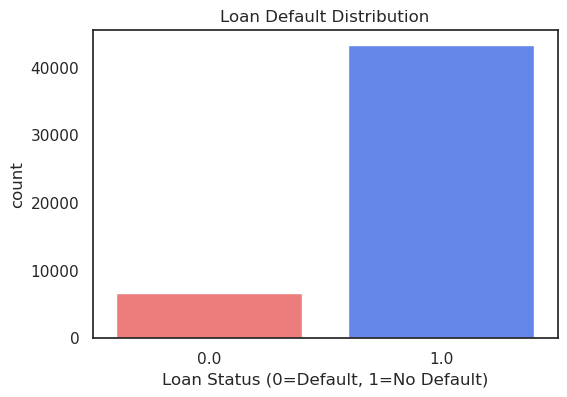

In [132]:
plt.figure(figsize=(6, 4))
# Simplemente le pasamos la columna y él cuenta solo
sns.countplot(x=df['loan_status_binary'], palette=['#ff6b6b', '#4d7cfe']) 
plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0=Default, 1=No Default)")
plt.show()


loan_status_binary
1.0    43329
0.0     6621
Name: count, dtype: int64


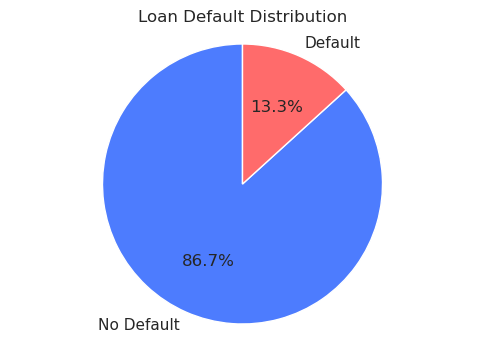

In [133]:
print(df['loan_status_binary'].value_counts())
plt.figure(figsize=(6, 4))
plt.pie(
    df['loan_status_binary'].value_counts(),
    labels=["No Default", "Default"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4d7cfe", "#ff6b6b"]
)
plt.title("Loan Default Distribution")
plt.axis("equal")  # para que sea un círculo perfecto
plt.show()

###  Target Variable Distribution

>The target variable represents whether a loan applicant defaulted (0) or not (1).  
>This chart helps us understand class balance and assess whether special treatment (e.g., class weights, resampling) might be needed.


## 3. Missing values
> Check the missing values. columns that are missing by more than 35 percent will be removed.

In [134]:
def missing_data_summary(df, threshold=0):
    """
    Summarizes missing data, showing count and percentage of missing values for each column.
    Filters columns based on a missing percentage threshold.
    
    Parameters:
        df (pd.DataFrame): The dataframe to analyze.
        threshold (float): The minimum percentage of missing data to include in the summary.
    
    Returns:
        pd.DataFrame: A summary of missing data.
    """
    return (pd.DataFrame(df.isna().sum())
            .reset_index()
            .rename(columns={'index': 'Column', 0: 'mis_count'})
            .query('mis_count > 0')  # Only include columns with missing values
            .assign(Missing_Percentage=lambda x: x['mis_count'] / df.shape[0] * 100)
            .query(f'Missing_Percentage > {threshold}')  # Filter by threshold
            .sort_values('mis_count', ascending=False)
            .reset_index(drop=True))

missing = missing_data_summary(df, threshold = 35)
missing

,Column,mis_count,Missing_Percentage
0,hardship_last_payment_amount,49783,99.566
1,hardship_end_date,49783,99.566
2,hardship_type,49783,99.566
3,hardship_status,49783,99.566
4,deferral_term,49783,99.566
5,hardship_start_date,49783,99.566
6,hardship_amount,49783,99.566
7,payment_plan_start_date,49783,99.566
8,hardship_length,49783,99.566
9,hardship_dpd,49783,99.566


In [135]:
# Convert the first column of 'missing' to a list
columns_to_drop = missing.iloc[:, 0].tolist()

# Drop these columns from the DataFrame 'df'
# df = df.drop(columns=columns_to_drop, errors='ignore')  # 'errors="ignore"' ensures no error if a column is missing

# Categóricas → "N/A"
cat_cols = df[columns_to_drop].select_dtypes(include=["object", "category"]).columns
df[cat_cols] = df[cat_cols].fillna("N/A")

# Numéricas → 0
num_cols = df[columns_to_drop].select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(0)


In [136]:
df.shape

(50000, 93)

#### Drop rows where 'loan_status_binary' is NaN

In [137]:
#Drop rows where 'loan_status_binary' is NaN 
df.dropna(subset=['loan_status_binary'], inplace=True)

In [138]:
df.shape

(49950, 93)

>Only over a half have passed the filter of missing values because more they had a greater percentage of missing (or nan) values


###  Missing Data Summary

> To ensure the stability and reliability of the credit scoring model, we start by analyzing missing values. Excessive missing data in a variable can lead to biased models, distorted statistics, and misleading business decisions.

####  Key Actions:

* Columns with more than **35% missing data** have been removed.
* The chart below highlights the **top 10 features** with the highest proportion of missing values.
* Remaining features with moderate missing values will be imputed or engineered appropriately.

 *Note: Removing high-missing columns helps reduce noise, while imputing moderately incomplete data can preserve valuable signal for modeling.*


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49950 entries, 0 to 49999
Data columns (total 93 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   initial_list_status                  49950 non-null  object 
 1   acc_now_delinq                       49950 non-null  float64
 2   acc_open_past_24mths                 48927 non-null  float64
 3   all_util                             49950 non-null  float64
 4   annual_inc                           49950 non-null  float64
 5   annual_inc_joint                     49950 non-null  float64
 6   application_type                     49950 non-null  object 
 7   avg_cur_bal                          48473 non-null  float64
 8   bc_util                              48365 non-null  float64
 9   chargeoff_within_12_mths             49949 non-null  float64
 10  collections_12_mths_ex_med           49949 non-null  float64
 11  delinq_2yrs                      

>Still there are several null values that will be corrected later. 

In [140]:
# threshold: more than 7 NaN values
threshold = 7
rows1 = df.shape[0]

df = df.dropna(thresh=threshold)

rows2 = df.shape[0]
print(f"Dropped {rows1 - rows2} rows with more than 7 missing values.")

df.shape

Dropped 0 rows with more than 7 missing values.


(49950, 93)

## 4. Categorical Features

In [141]:
df.select_dtypes(include=['object','int64', 'int32']).nunique()

initial_list_status            2
application_type               2
emp_length                    11
grade                          7
home_ownership                 6
purpose                       14
pymnt_plan                     2
term                           2
verification_status            3
verification_status_joint      4
hardship_flag                  2
hardship_type                  2
hardship_status                4
hardship_start_date           25
hardship_end_date             26
payment_plan_start_date       25
hardship_loan_status           5
last_pymnt_d                 119
issue_d                      134
disbursement_method            2
debt_settlement_flag           2
addr_state                    50
dtype: int64

### Objects
> First let's check the 'object' columns. We see that there are some columns that can be transformed to date or numeric columns.

In [142]:
df.select_dtypes(include=['object']).head()

,initial_list_status,application_type,emp_length,grade,home_ownership,purpose,pymnt_plan,term,verification_status,verification_status_joint,hardship_flag,hardship_type,hardship_status,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_loan_status,last_pymnt_d,issue_d,disbursement_method,debt_settlement_flag,addr_state
0,w,Individual,10+ years,A,MORTGAGE,debt_consolidation,n,36 months,Not Verified,N/A,N,N/A,N/A,N/A,N/A,N/A,N/A,Sep-2016,Dec-2015,Cash,N,VA
1,w,Individual,5 years,D,RENT,credit_card,n,60 months,Not Verified,N/A,N,N/A,N/A,N/A,N/A,N/A,N/A,Nov-2017,Dec-2015,Cash,N,OH
2,w,Individual,10+ years,B,MORTGAGE,debt_consolidation,n,60 months,Not Verified,N/A,N,N/A,N/A,N/A,N/A,N/A,N/A,Nov-2017,Dec-2015,Cash,N,KS
3,w,Individual,3 years,C,OWN,debt_consolidation,n,36 months,Source Verified,N/A,N,N/A,N/A,N/A,N/A,N/A,N/A,Jul-2018,Dec-2015,Cash,N,NC
4,w,Individual,10+ years,D,RENT,debt_consolidation,n,60 months,Not Verified,N/A,N,N/A,N/A,N/A,N/A,N/A,N/A,Mar-2016,Dec-2015,Cash,N,NV


In [143]:
# Remove leading/trailing whitespaces from objects
df = df.apply(lambda col: col.str.strip() if col.dtypes == 'object' else col)

import locale

def procesar_fechas(df, columnas, formato_fecha='%b-%Y'):
    """
    Convierte las columnas indicadas a datetime.
    - Maneja el locale (para meses en inglés: Dec, Jan, etc.).
    - Convierte 'N/A', strings vacíos o formatos erróneos a NaT (el NaN de las fechas).
    """
    
    # 1. Intentamos poner el locale en Inglés para que entienda 'Dec', 'Apr', etc.
    try:
        locale.setlocale(locale.LC_TIME, 'English')
    except:
        try:
            # Fallback común para entornos Linux/Mac/Cloud
            locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')
        except Exception as e:
            print(f"Advertencia: No se pudo cambiar el locale. {e}")

    # 2. Bucle de conversión
    for col in columnas:
        if col in df.columns:
            # errors='coerce' transforma cualquier error (incluido el string "N/A") en NaT
            df[col] = pd.to_datetime(df[col], format=formato_fecha, errors='coerce')
        else:
            print(f"Ojo: La columna '{col}' no está en el DataFrame.")
            
    return df



# Lista de tus columnas de fechas (basada en tu código anterior)
cols_fechas = [
    'issue_d', 
    'last_pymnt_d', 
    'hardship_end_date', 
    'hardship_start_date', 
    'payment_plan_start_date'
    # 'earliest_cr_line', # Descomenta si la necesitas
    # 'last_credit_pull_d' # Descomenta si la necesitas
]

# Aplicamos la función
df = procesar_fechas(df, cols_fechas)

# int_rate and revol_util for int type
# Convertimos a string primero (.astype(str)) para evitar el error si ya es numérico
df['int_rate%'] = pd.to_numeric(df['int_rate'].astype(str).str.strip('%'), errors='coerce')
# df['revol_util%'] = pd.to_numeric(df['revol_util'].astype(str).str.strip('%'), errors='coerce')

# columns_to_drop={'int_rate','revol_util'}
columns_to_drop = {'int_rate'}
df.drop(columns_to_drop, axis = 1, inplace = True)


df['emp_length'] = df['emp_length'].fillna('')
df['emp_length'] = pd.to_numeric(df['emp_length'].str.replace('<', '', regex=False).str[:2].str.strip(), errors='coerce')
df['emp_length'].fillna(0.0, inplace=True)

df['hardship_flag'].fillna('N', inplace=True) #it looks like the Nans are as strings so
df['hardship_flag'] = np.where( df['hardship_flag'] == 'NaN','N', df['hardship_flag'] )

In [144]:
def get_sorted_unique_counts(df):
    # Select columns with categorical data
    object_cols = df.select_dtypes(include=['object', 'category']).columns
    
    # Get the number of unique entries in each categorical column
    object_nunique = {col: df[col].nunique() for col in object_cols}
    
    # Convert to DataFrame and sort by unique counts
    unique_counts = pd.DataFrame(list(object_nunique.items()), columns=['Column', 'Unique Count'])
    unique_counts = unique_counts.sort_values(by='Unique Count').reset_index(drop=True)
    
    return unique_counts

get_sorted_unique_counts(df)

,Column,Unique Count
0,initial_list_status,2
1,application_type,2
2,pymnt_plan,2
3,term,2
4,hardship_flag,2
5,hardship_type,2
6,disbursement_method,2
7,debt_settlement_flag,2
8,verification_status,3
9,verification_status_joint,4


In [145]:
df[df.select_dtypes(include=['object', 'category']).columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 49950 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   initial_list_status        49950 non-null  object
 1   application_type           49950 non-null  object
 2   grade                      49950 non-null  object
 3   home_ownership             49950 non-null  object
 4   purpose                    49950 non-null  object
 5   pymnt_plan                 49950 non-null  object
 6   term                       49950 non-null  object
 7   verification_status        49950 non-null  object
 8   verification_status_joint  49950 non-null  object
 9   hardship_flag              49950 non-null  object
 10  hardship_type              49950 non-null  object
 11  hardship_status            49950 non-null  object
 12  hardship_loan_status       49950 non-null  object
 13  disbursement_method        49950 non-null  object
 14  debt_settle

In [146]:
# Mantener como NaN
df[df.select_dtypes(include=['object', 'category']).columns] = df[df.select_dtypes(include=['object', 'category']).columns].replace("N/A", np.nan)


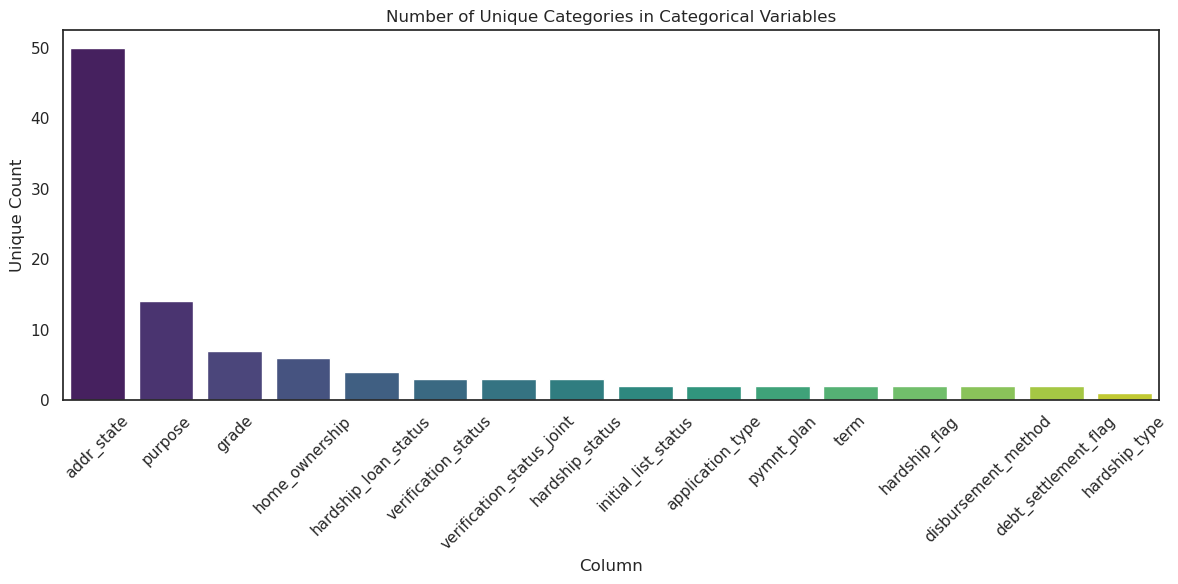

In [147]:
# 1. Calculamos los valores únicos por columna (solo las categóricas)
# Esto sustituye a tu función 'get_sorted_unique_counts'
unique_counts = df.select_dtypes(include=['object', 'category']).nunique().sort_values(ascending=False).reset_index()
unique_counts.columns = ['Column', 'Unique Count']

# 2. Graficamos con Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=unique_counts, x='Column', y='Unique Count', palette='viridis')

# Detalles estéticos básicos
plt.title("Number of Unique Categories in Categorical Variables")
plt.xticks(rotation=45) # Rotamos los nombres para que se lean bien
plt.tight_layout()
plt.show()


> Check how many unique values are in object columns. We check if binning is needed.
Check all for any inconsistences or imbalances

#### REVIEWING IN MORE DETAIL TO DISCARD THE CATEGORICAL VARIABLES

Imagen guardada como: distribution_purpose.png


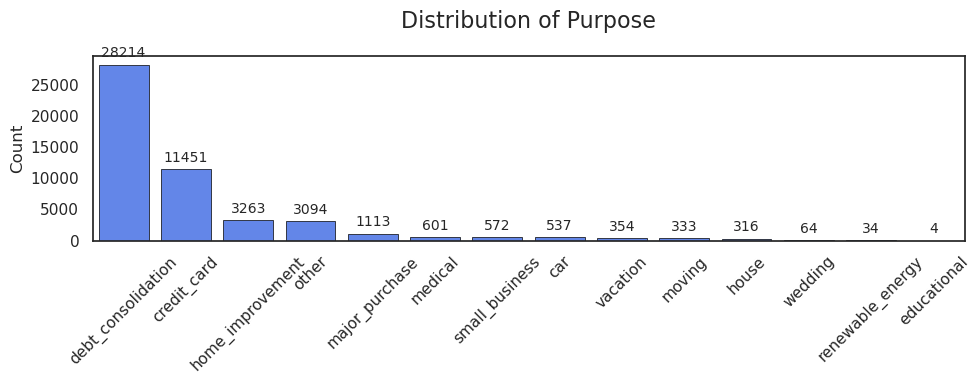

Imagen guardada como: distribution_purpose_pie.png


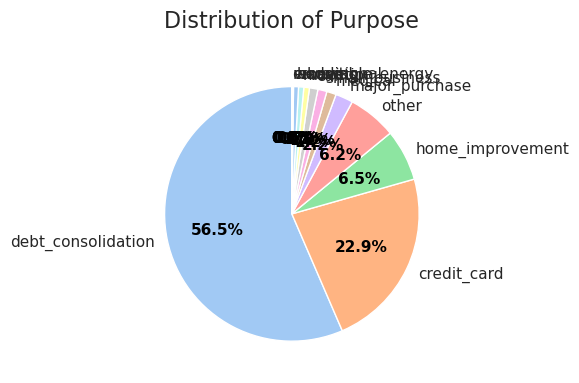

In [148]:
# PURPOSE
value_counts = df["purpose"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Purpose",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_purpose")

fig = plot_pie(
    labels=labels,
    values=values,
    title="Distribution of Purpose",
    height=400
)
save_and_display(fig, "distribution_purpose_pie")


Imagen guardada como: distribution_home_ownership.png


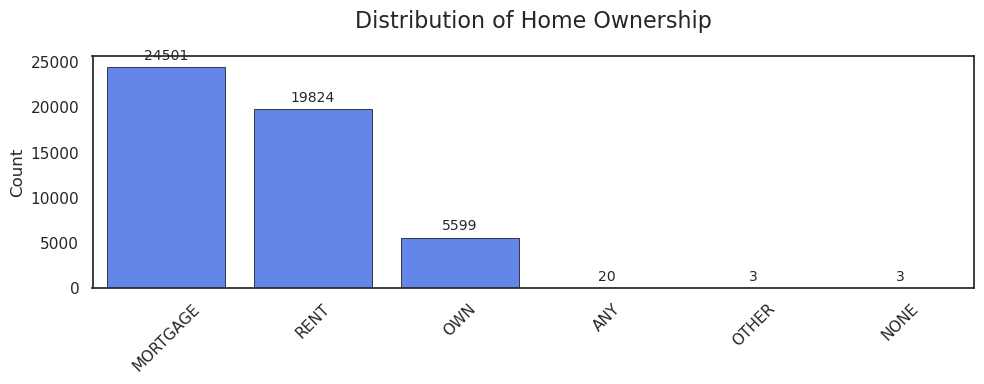

In [149]:
# HOME_OWNERSHIP
value_counts = df["home_ownership"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Home Ownership",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_home_ownership")


Imagen guardada como: distribution_application_type.png


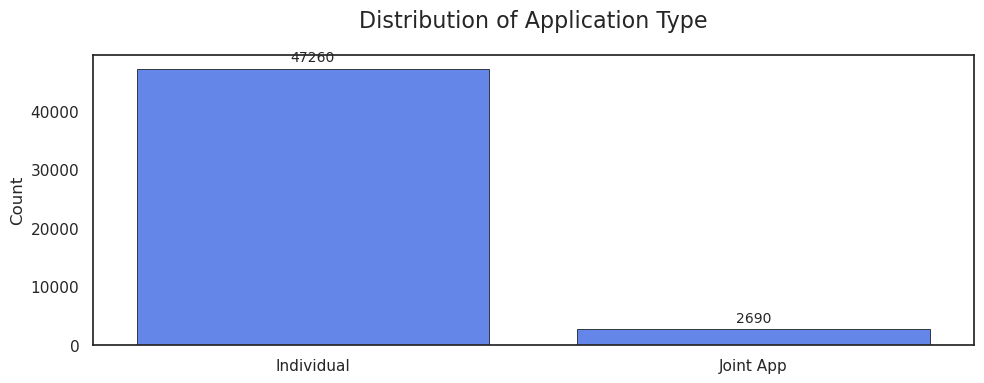

Imagen guardada como: distribution_application_type_pie.png


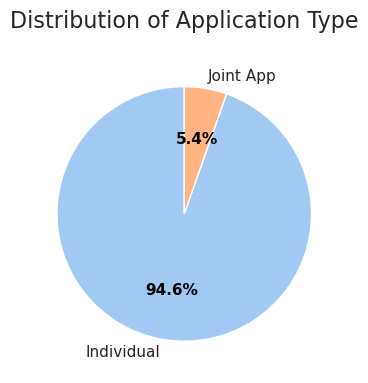

In [150]:
# APPLICATION_TYPE
value_counts = df["application_type"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Application Type",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_application_type")

fig2 = plot_pie(
    labels=labels,
    values=values,
    title="Distribution of Application Type",
    height=400
)
save_and_display(fig2, "distribution_application_type_pie")


Imagen guardada como: distribution_grade.png


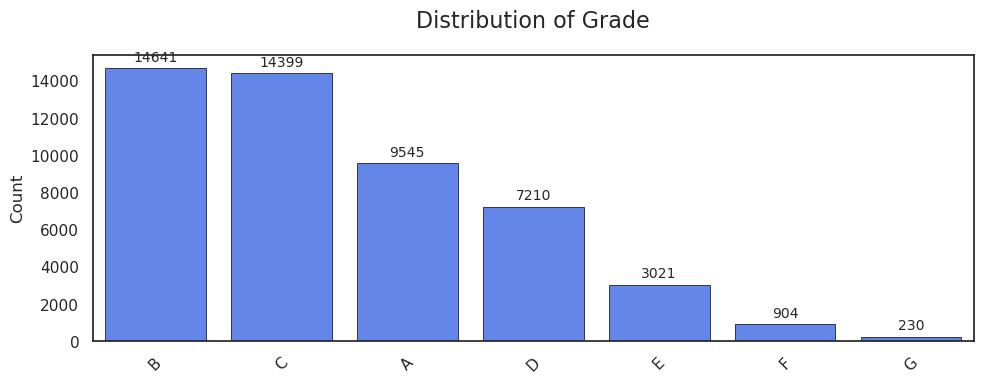

Imagen guardada como: distribution_grade_pie.png


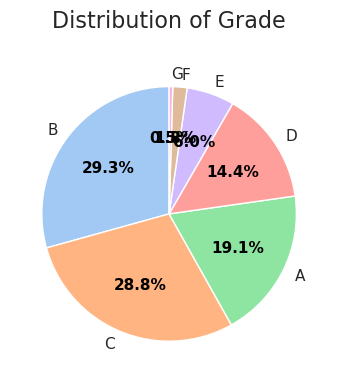

In [151]:
# GRADE
value_counts = df["grade"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Grade",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_grade")
fig2 = plot_pie(
    labels=labels,
    values=values,
    title="Distribution of Grade",
    height=400
)
save_and_display(fig2, "distribution_grade_pie")

Imagen guardada como: distribution_disbursement_method.png


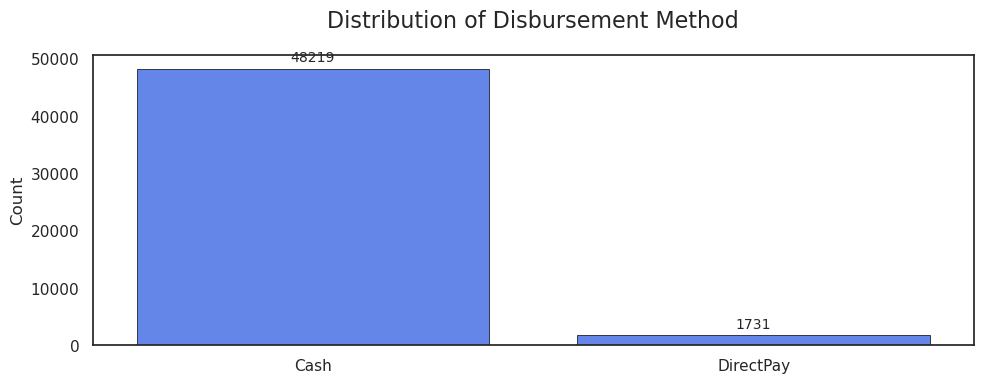

Imagen guardada como: distribution_disbursement_method_pie.png


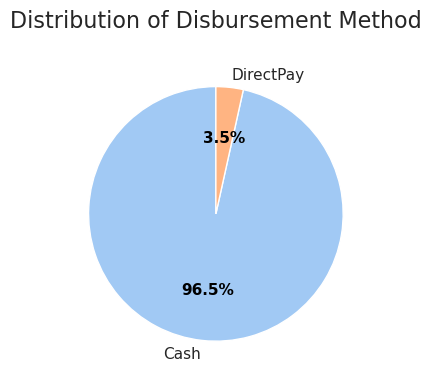

In [152]:
# DISBUREMENT_METHOD
value_counts = df["disbursement_method"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Disbursement Method",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_disbursement_method")
fig2 = plot_pie(
    labels=labels,
    values=values,
    title="Distribution of Disbursement Method",
    height=400
)
save_and_display(fig2, "distribution_disbursement_method_pie")

Imagen guardada como: distribution_payment_plan.png


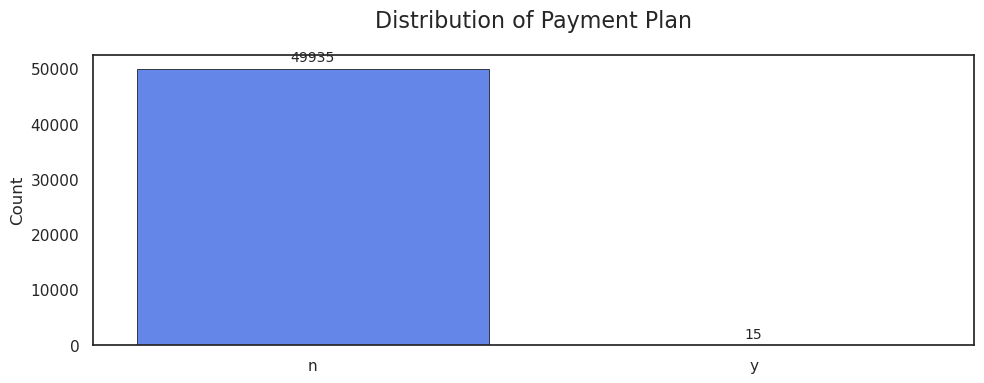

Imagen guardada como: distribution_payment_plan_pie.png


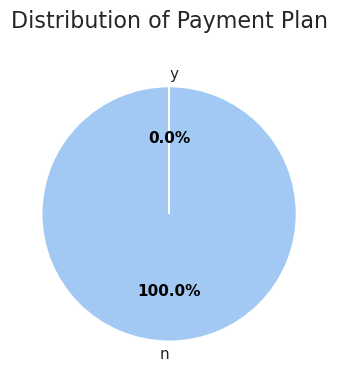

In [153]:
# PAYMENT_PLAN
value_counts = df["pymnt_plan"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Payment Plan",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_payment_plan")
fig2 = plot_pie(
    labels=labels,
    values=values,
    title="Distribution of Payment Plan",
    height=400
)
save_and_display(fig2, "distribution_payment_plan_pie")

Imagen guardada como: distribution_initial_list_status.png


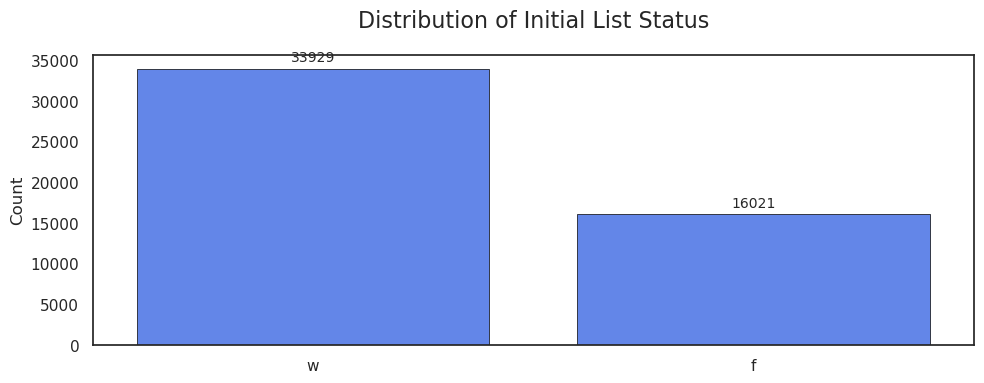

Imagen guardada como: distribution_initial_list_status_pie.png


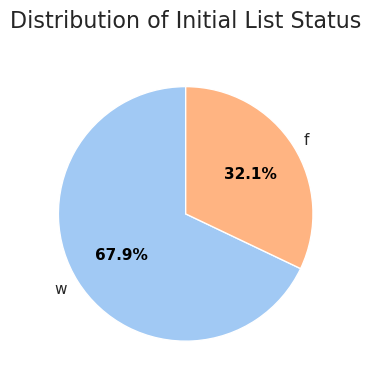

In [154]:
# INITIAL_LIST_STATUS
value_counts = df["initial_list_status"].value_counts(dropna=False).sort_values(ascending=False)
labels = value_counts.index.astype(str).tolist()
values = value_counts.values.tolist()
gradients = [("#4d7cfe", "#97f3ff")] * len(labels)

fig = plot_gradient_bar(
    labels=labels,
    values=values,
    gradients=gradients,
    title="Distribution of Initial List Status",
    bar_width=0.55,
    height=400
)
save_and_display(fig, "distribution_initial_list_status")
fig2 = plot_pie(
    labels=labels,
    values=values,
    title="Distribution of Initial List Status",
    height=400
)
save_and_display(fig2, "distribution_initial_list_status_pie")

In [155]:
def value_counter(df):
    rows = []

    for col in df.select_dtypes(include=["object"]).columns:
        vc = df[col].value_counts(dropna=False)
        total = vc.sum()

        for value, count in vc.items():
            rows.append({
                "variable": col,
                "value": value,
                "count": count,
                "percentage": round(100 * count / total, 2)

            })

    result_df = pd.DataFrame(rows)

    # Ordenar para que quede agrupado por variable y por frecuencia
    result_df = result_df.sort_values(
        by=["variable", "count"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return result_df

In [156]:
value_counter_df = value_counter(df)
display(value_counter_df)

,variable,value,count,percentage
0,addr_state,CA,7123,14.26
1,addr_state,TX,4043,8.09
2,addr_state,NY,4042,8.09
3,addr_state,FL,3531,7.07
4,addr_state,IL,1995,3.99
...,...,...,...,...
104,verification_status,Verified,14017,28.06
105,verification_status_joint,NaN,47379,94.85
106,verification_status_joint,Not Verified,1304,2.61
107,verification_status_joint,Source Verified,727,1.46


In [157]:
# for col in df.select_dtypes(['object']).columns:
#     print(f"Column: {col}")
#     plot_pie(labels=df[col].value_counts(dropna=False)[0:].index.tolist(),
#              values=df[col].value_counts(dropna=False).values.tolist(),
#              title=f"Distribution of {col}",
#              height=400)
#     print("\n")

###  Key Observations on Categorical Variables

>  **`sub_grade`** is already hierarchically grouped via `grade`, so it may be redundant in modeling.
>
> **`home_ownership`** shows strong imbalance: `MORTGAGE` and `RENT` dominate, while `OWN` and especially `OTHER` are underrepresented. This can lead to **bias in classification models**, favoring majority classes. Consider combining sparse categories.
>
>  **`purpose`** has several rarely used categories such as `medical`, `vacation`, `wedding`, `renewable_energy`, and `educational`. These low-frequency classes might **increase model variance** and can be safely grouped under `"other"`.
>
>  **`addr_state`** has 51 unique values and might be too granular for most models. Possible actions:
>
> * Grouping by **US regions**
> * Creating **risk-level clusters**
> * Dropping if uninformative


In [158]:
# df.drop('sub_grade', axis=1, inplace = True)

# 🔍Using WoE & IV for categorical features

>Now we will group categorical data based on Weight of Evidence (WoE) and create a table with relevant measures.
> **WoE**: WoE is computed as:<br>
> "Non-Event" - bad = '0' defaulted loans, <br>
> "Event"     - good = '1' non-default loans.<br>

$$
\text{WoE} = \ln\left(\frac{\text{Proportion of Non-Event}}{\text{Proportion of Event}}\right)
$$


> **IV (Information Value)** indicates the predictive power of the categorical variable. Total IV: Interpret the IV to understand the variable's predictive strength.

$$
\text{IV} = \sum \left( (\text{Proportion of Non-Event} - \text{Proportion of Event}) \cdot \text{WoE} \right)
$$

>Interpretation of IV:<br>
> < 0.02: Not Predictive <br>
> 0.02 - 0.1: Weak Predictive Power<br>
> 0.1 - 0.3: Medium Predictive Power<br>
> 0.3+: Strong Predictive Power<br>
> IV > 0.5: Suspiciously strong — Could indicate overfitting or data issues.

In [159]:
def process_categorical_columns(df, categorical_cols, target_col, woe_table=None, iv_summary=None, append=False):
    """
    Calculate WoE and IV for given categorical columns, including NaNs as a separate category.
    
    Args:
        df (pd.DataFrame): Input DataFrame.
        categorical_cols (list): List of categorical column names to process.
        target_col (str): Name of the binary target column (1 = Good, 0 = Bad).
        woe_table (pd.DataFrame): Existing WoE table (required if append=True).
        iv_summary (pd.DataFrame): Existing IV summary (required if append=True).
        append (bool): If True, append results to existing tables.
    
    Returns:
        woe_table (pd.DataFrame): WoE table with all processed columns.
        iv_summary (pd.DataFrame): IV summary table with all processed columns.
    """
    if append and (woe_table is None or iv_summary is None):
        raise ValueError("Existing tables must be provided when append=True.")
    
    # Initialize results if not appending
    if not append:
        woe_table = pd.DataFrame()
        iv_summary = pd.DataFrame()
    
    new_woe_results = []
    new_summary = []

    # Process each categorical column
    for col in categorical_cols:
        # Handle NaN values by creating a separate 'NaN' category
        df[col] = df[col].fillna('NaN')
        
        # Group by the column to calculate metrics
        stats = df.groupby(col).agg(
            event_count=(target_col, 'sum'),
            total_count=(target_col, 'count')
        ).reset_index()

        # Calculate non-event count and proportions
        stats['non_event_count'] = stats['total_count'] - stats['event_count']
        total_events = stats['event_count'].sum()
        total_non_events = stats['non_event_count'].sum()

        # Avoid division by zero
        stats['event_rate'] = stats['event_count'] / (total_events + 1e-6)
        stats['non_event_rate'] = stats['non_event_count'] / (total_non_events + 1e-6)

        # Calculate WoE
        stats['woe'] = np.log((stats['non_event_rate'] + 1e-6) / (stats['event_rate'] + 1e-6))
        
        # Calculate IV for each category
        stats['iv'] = (stats['non_event_rate'] - stats['event_rate']) * stats['woe']
        
        # Compute total IV for the column
        total_iv = stats['iv'].sum()

        # Add column name and rename for desired format
        stats['name'] = col  # Add column name
        stats.rename(columns={col: 'sub_name'}, inplace=True)  # Rename column to 'sub_name'
        
        # Reorder columns
        stats = stats[['name', 'sub_name', 'event_count', 'total_count', 'non_event_count', 
                       'event_rate', 'non_event_rate', 'woe', 'iv']]

        # Append results
        new_woe_results.append(stats)
        new_summary.append({'Column': col, 'IV': total_iv})

    # Combine results with existing tables if appending
    new_woe_table = pd.concat(new_woe_results, ignore_index=True)
    new_iv_summary = pd.DataFrame(new_summary).sort_values(by='IV', ascending=False)

    if append:
        woe_table = pd.concat([woe_table, new_woe_table], ignore_index=True)
        iv_summary = pd.concat([iv_summary, new_iv_summary], ignore_index=True).sort_values(by='IV', ascending=False)
    else:
        woe_table = new_woe_table
        iv_summary = new_iv_summary

    return woe_table, iv_summary

In [160]:
# Initial processing
categorical_cols = df.select_dtypes(include=['object']).columns
woe_table, iv_summary = process_categorical_columns(df, categorical_cols, 'loan_status_binary')

# Save initial results
# woe_table.to_csv('woe_table.csv', index=False)
# iv_summary.to_csv('iv_summary.csv', index=False)

iv_summary

,Column,IV
14,debt_settlement_flag,0.974238
2,grade,0.469717
7,verification_status,0.078076
6,term,0.062844
13,disbursement_method,0.062647
11,hardship_status,0.058090
12,hardship_loan_status,0.036288
10,hardship_type,0.031505
4,purpose,0.030179
3,home_ownership,0.026391


>A **FSS (Feature Subset Selection)** can be performed, extracting the variables below a certain IV value

In [161]:
#dropping where IV < 0.02
# drop = {'application_type','initial_list_status','addr_state','purpose'}
# df.drop(drop, axis=1, inplace=True)

df.drop({'pymnt_plan','disbursement_method', 'hardship_flag'}, axis=1, inplace=True)

In [162]:
print("Initial WoE Table:")
woe_table[woe_table.name == 'hardship_flag']

Initial WoE Table:


,name,sub_name,event_count,total_count,non_event_count,event_rate,non_event_rate,woe,iv
42,hardship_flag,N,43329.0,49934,6605.0,1.0,0.997583,-0.002419,0.000006
43,hardship_flag,Y,0.0,16,16.0,0.0,0.002417,7.790511,0.018826


In [163]:
print("Initial WoE Table:")
woe_table[woe_table.name == 'verification_status']

Initial WoE Table:


,name,sub_name,event_count,total_count,non_event_count,event_rate,non_event_rate,woe,iv
35,verification_status,Not Verified,14900.0,16417,1517.0,0.343881,0.229119,-0.406049,0.046599
36,verification_status,Source Verified,16835.0,19516,2681.0,0.388539,0.404924,0.041305,0.000677
37,verification_status,Verified,11594.0,14017,2423.0,0.267581,0.365957,0.313093,0.030801


In [164]:
print("Initial WoE Table:")
woe_table[woe_table.name == 'home_ownership']

Initial WoE Table:


,name,sub_name,event_count,total_count,non_event_count,event_rate,non_event_rate,woe,iv
11,home_ownership,ANY,18.0,20,2.0,0.000415,0.000302,-0.317748,0.000036
12,home_ownership,MORTGAGE,21674.0,24501,2827.0,0.500219,0.426975,-0.158321,0.011596
13,home_ownership,NONE,3.0,3,0.0,0.000069,0.000000,-4.251885,0.000294
14,home_ownership,OTHER,3.0,3,0.0,0.000069,0.000000,-4.251885,0.000294
15,home_ownership,OWN,4878.0,5599,721.0,0.112580,0.108896,-0.033275,0.000123
16,home_ownership,RENT,16753.0,19824,3071.0,0.386646,0.463827,0.182001,0.014047


> As we see the WoE, IV and total counts numbers we can group the 'ANY', 'MORTGAGE' and 'NONE' together.

In [165]:
home_ownership_mapping = {
    'ANY' : 'other',
    'MORTGAGE' : 'mortgage',
    'RENT' : 'rent',
    'OWN' : 'own',
    'NONE' : 'other',
    'OTHER' : 'other'
}
df.home_ownership = df.home_ownership.map(home_ownership_mapping)

### 📊 Checking categorical features vs target

For a later, more complex study, `grade` variable can be eraised to be fairer. 

Imagen guardada como: stacked_grade.png


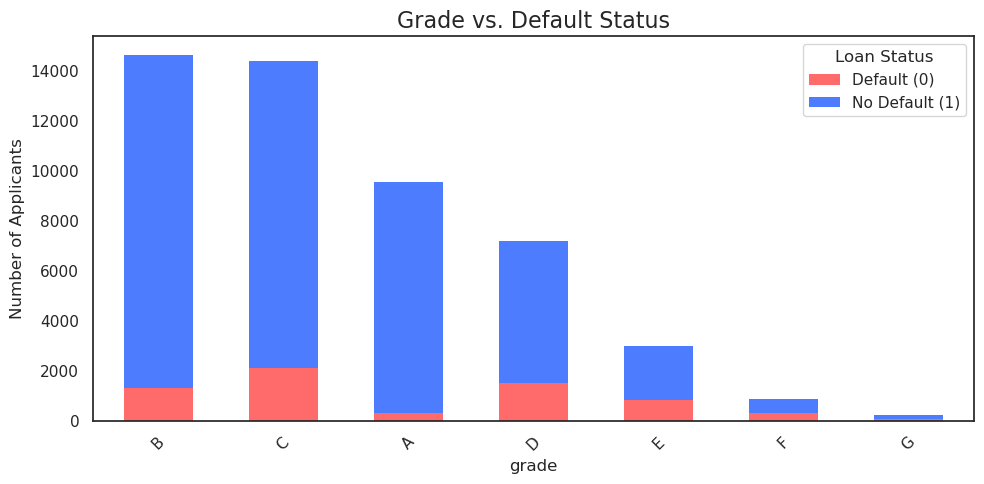

In [166]:
# GRADE
fig = plot_stacked_categorical_gradient(
    df,
    col="grade",
    title="Grade vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_grade")


Imagen guardada como: stacked_verification_status.png


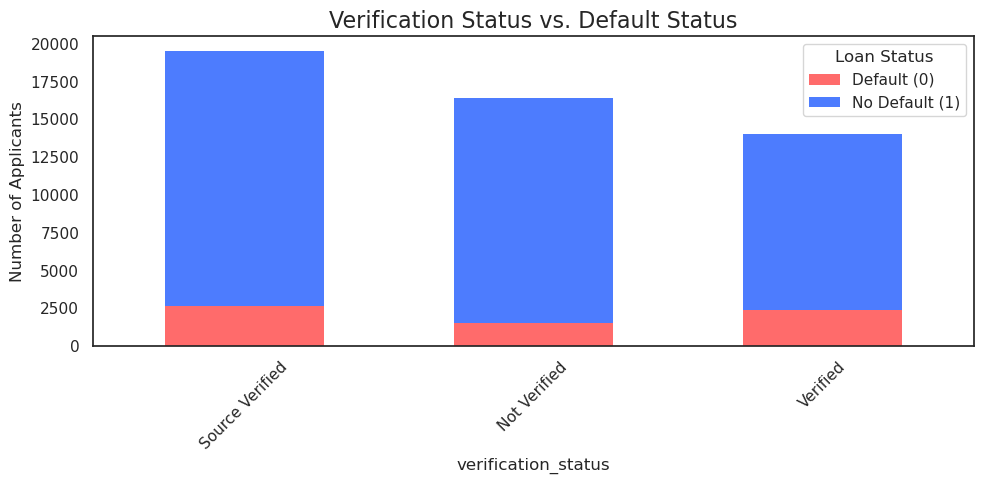

In [167]:
# VERIFICATION_STATUS
fig = plot_stacked_categorical_gradient(
    df,
    col="verification_status",
    title="Verification Status vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_verification_status")


Imagen guardada como: stacked_home_ownership.png


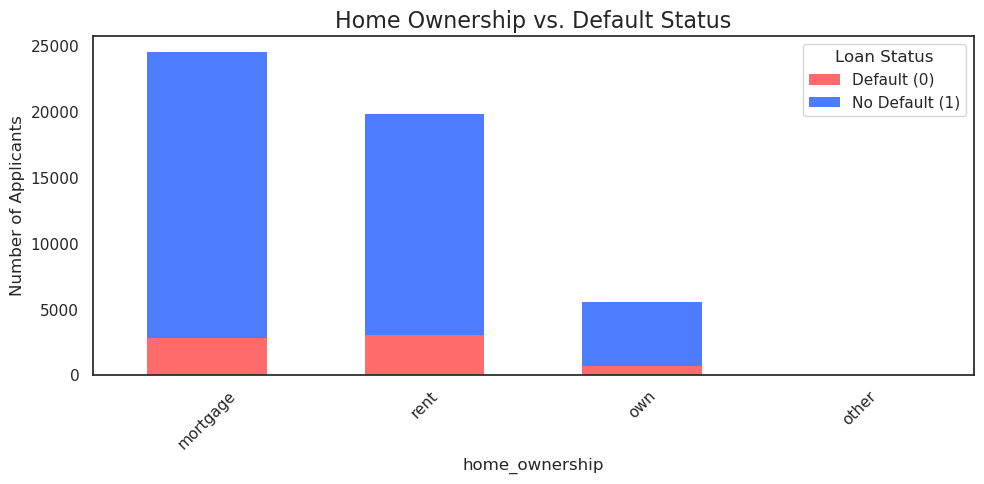

In [168]:
# HOME_OWNERSHIP
fig = plot_stacked_categorical_gradient(
    df,
    col="home_ownership",
    title="Home Ownership vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_home_ownership")


> Too many states. They will be reduced into 5: `West`, `North`, `East`, `South` and `Centre`

In [169]:
state_regions = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast",
    "NH": "Northeast", "RI": "Northeast", "VT": "Northeast",
    "NJ": "Northeast", "NY": "Northeast", "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest",
    "OH": "Midwest", "WI": "Midwest", "IA": "Midwest",
    "KS": "Midwest", "MN": "Midwest", "MO": "Midwest",
    "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South",
    "NC": "South", "SC": "South", "VA": "South", "WV": "South",
    "AL": "South", "KY": "South", "MS": "South", "TN": "South",
    "AR": "South", "LA": "South", "OK": "South", "TX": "South",
    "DC": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West",
    "NV": "West", "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West", "OR": "West",
    "WA": "West"
}

df["addr_state"] = df["addr_state"].map(state_regions).dropna()


Imagen guardada como: stacked_addr_state.png


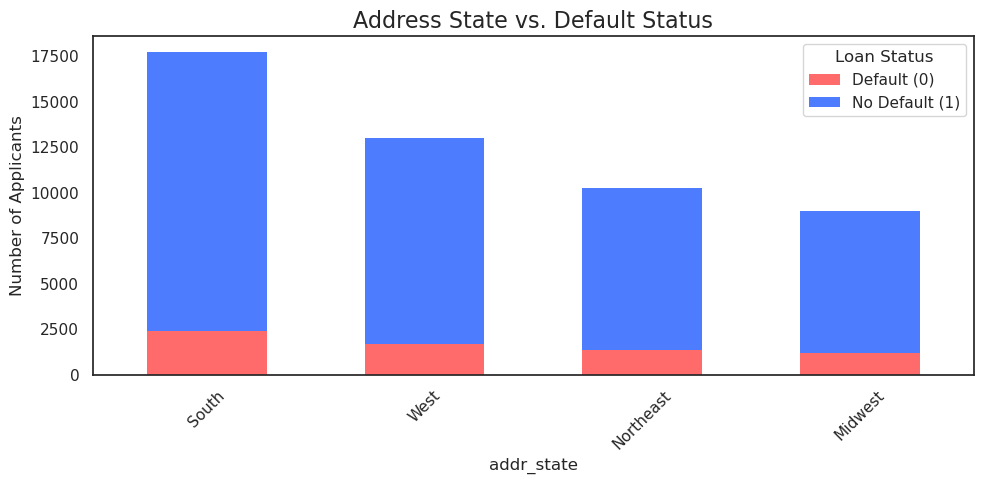

In [170]:
#STATE ADRESS
fig = plot_stacked_categorical_gradient(
    df,
    col="addr_state",
    title="Address State vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_addr_state")

Imagen guardada como: stacked_purpose.png


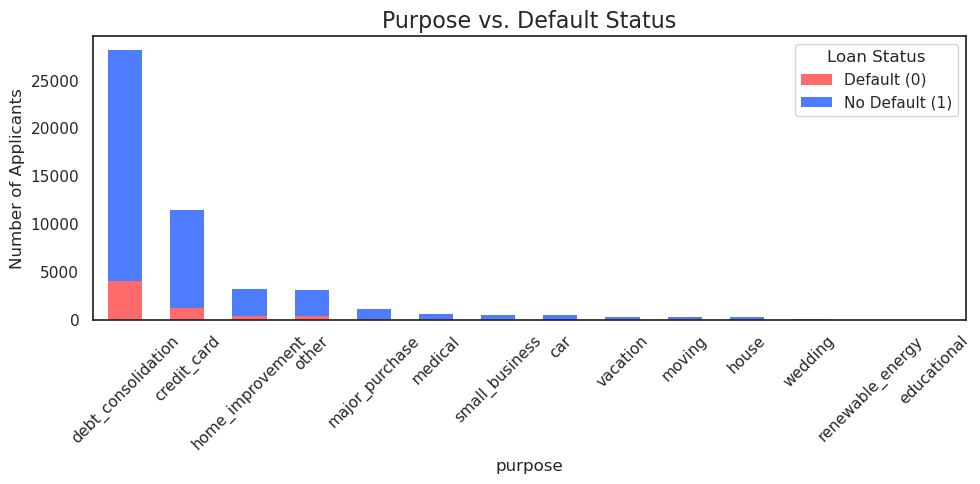

In [171]:
#PURPOSE
fig = plot_stacked_categorical_gradient(
    df,
    col="purpose",
    title="Purpose vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_purpose")

Imagen guardada como: stacked_application_type.png


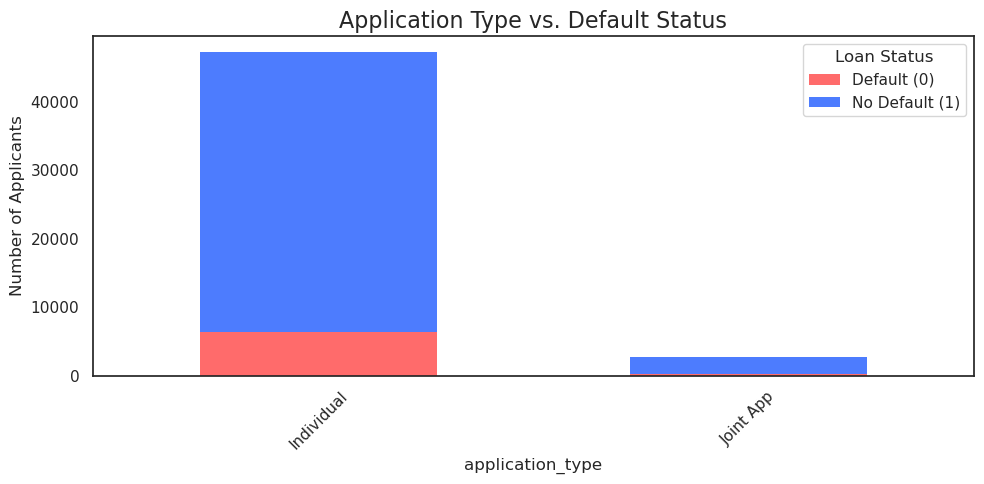

In [172]:
#APPLICATION TYPE
fig = plot_stacked_categorical_gradient(
    df,
    col="application_type",
    title="Application Type vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_application_type")

Imagen guardada como: stacked_initial_list_status.png


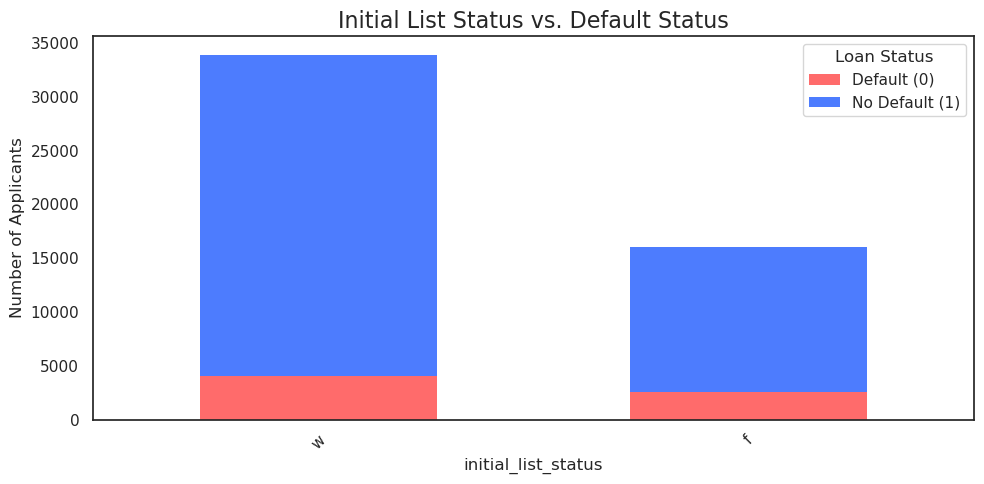

In [173]:
#INITIAL LIST STATUS
fig = plot_stacked_categorical_gradient(
    df,
    col="initial_list_status",
    title="Initial List Status vs. Default Status",
    bar_width=0.55,
    height=500
)
save_and_display(fig, "stacked_initial_list_status")

## 5. Date features

>Date columns often contain valuable temporal information that can improve predictive modeling. Lets extract meaningful features from these date columns.



In [174]:
date_cols = df.select_dtypes(include=['datetime64']).columns
df[date_cols].head()

,hardship_start_date,hardship_end_date,payment_plan_start_date,last_pymnt_d,issue_d
0,NaT,NaT,NaT,2016-09-01,2015-12-01
1,NaT,NaT,NaT,2017-11-01,2015-12-01
2,NaT,NaT,NaT,2017-11-01,2015-12-01
3,NaT,NaT,NaT,2018-07-01,2015-12-01
4,NaT,NaT,NaT,2016-03-01,2015-12-01


In [175]:
df[date_cols].isna().sum()

hardship_start_date        49733
hardship_end_date          49733
payment_plan_start_date    49733
last_pymnt_d                  52
issue_d                        0
dtype: int64

In [176]:
from datetime import datetime

# Assuming 'today' as the current date
today = pd.to_datetime("today")

#impute a today date to distinguish missing values.
# df['last_pymnt_d'].fillna(today, inplace=True)
# df['last_credit_pull_d'].fillna(today, inplace=True)

# Time differences
# df['loan_age'] = (today - df['issue_d']).dt.days
# df['credit_history_length'] = (df['issue_d'] - df['earliest_cr_line']).dt.days
# df['time_since_last_payment'] = (today - df['last_pymnt_d']).dt.days
# df['time_since_last_credit_pull'] = (today - df['last_credit_pull_d']).dt.days

df['loan_age'] = (today - df['issue_d']).dt.days
df['time_since_last_payment'] = (df['issue_d'] - df['last_pymnt_d']).dt.days
df['hardship_start'] = (df['issue_d'] - df['hardship_start_date']).dt.days
df['payment_plan_start'] = (df['issue_d'] - df['payment_plan_start_date']).dt.days
df['hardship_duration'] = (df['hardship_start_date'] - df['hardship_end_date']).dt.days
  
# Temporal components
# df['issue_year'] = df['issue_d'].dt.year
# df['issue_month'] = df['issue_d'].dt.month

# Categorical flags
# df['recent_payment'] = (df['time_since_last_payment'] <= 30).astype(int)
# df['recent_credit_pull'] = (df['time_since_last_credit_pull'] <= 90).astype(int)

# drop = {'issue_d','earliest_cr_line','last_pymnt_d','last_credit_pull_d'}
drop = {'issue_d','hardship_start_date','last_pymnt_d','payment_plan_start_date', 'hardship_end_date'}
fill = {'loan_age', 'time_since_last_payment', 'hardship_start', 'payment_plan_start', 'hardship_duration'}
df[list(fill)].fillna(0, inplace=True)
df.drop(drop,axis=1, inplace=True)

In [177]:
df.shape

(49950, 90)

## 6. Numeric Features

In [178]:
y = df.loan_status_binary
cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(exclude=['object']).drop('loan_status_binary',axis=1).columns

# Concatenate numeric and categorical columns explicitly
df_final = pd.concat([df[num_cols], df[cat_cols]], axis=1)
# df_final = pd.concat([df[num_cols], pd.get_dummies(df[cat_cols], drop_first=True)], axis=1)

>Remove external scores

In [179]:
external_scores = {'last_fico_range_high','last_fico_range_low','fico_range_low', 'fico_range_high'}
num_cols = [col for col in num_cols if col not in external_scores]
df_final.drop(external_scores , axis=1, inplace=True)

For the missing values apply `simple imputer`. It fill with the variable mean the missing values in each column. (Only numerical variables).

In [180]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

df_final[num_cols] = imputer.fit_transform(df_final[num_cols])

df_final.isna().sum().sum()


np.int64(0)

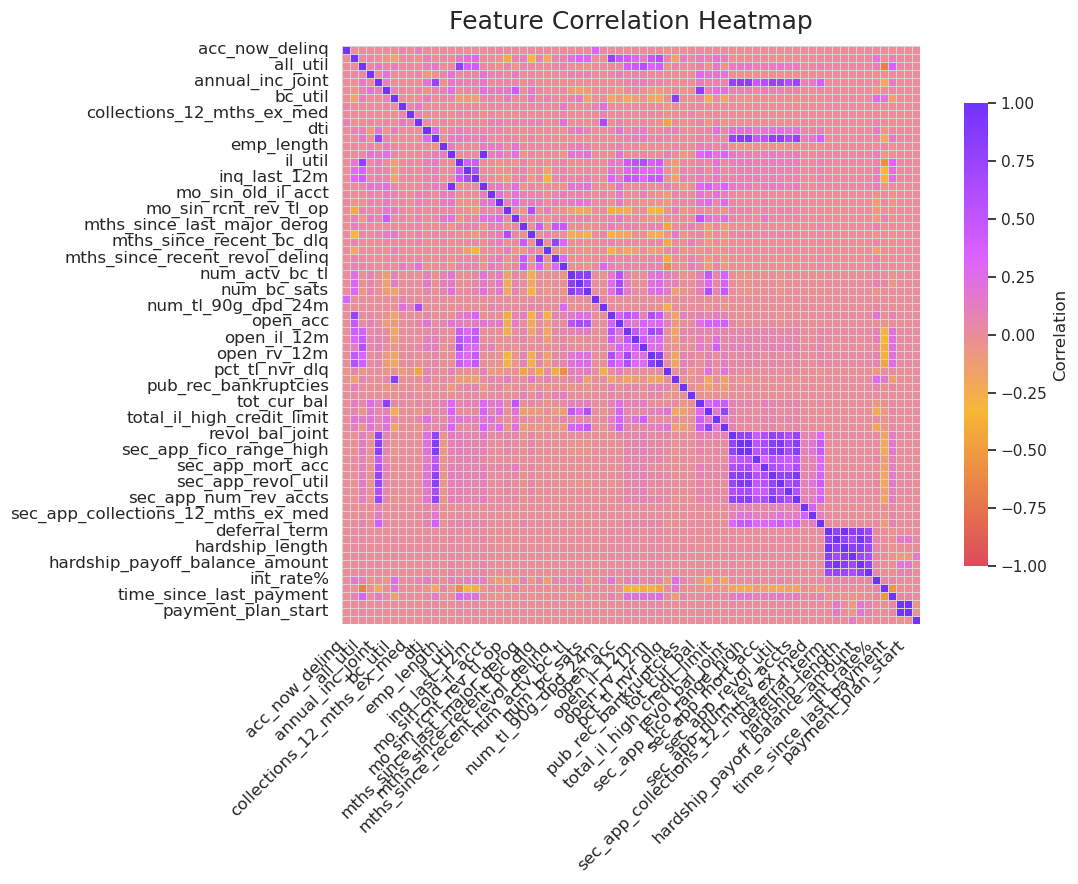

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


colors = ["#dc4b5b", "#f7b736", "#dd62ff", "#7132fb"]
custom_cmap = LinearSegmentedColormap.from_list("custom_gradient", colors, N=256)


feature_corr = df_final[num_cols].corr(method='pearson')


mask = (feature_corr.abs() > 0.5).any(axis=1)
filtered_corr = feature_corr.loc[mask, mask]


plt.figure(figsize=(12, 9))
sns.set(font="DejaVu Sans", style="white", rc={"axes.facecolor": "white"})

sns.heatmap(
    filtered_corr,
    cmap=custom_cmap,
    center=0,
    linewidths=0.5,
    linecolor='lightgray',
    square=True,
    annot=False,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    vmin=-1, vmax=1
)

plt.title("Feature Correlation Heatmap", fontsize=18, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()



>The heatmap above displays the most relevant correlations between features (|corr| > 0.5), allowing for better visibility and interpretability.


In [182]:
# Identify pairs of highly correlated features
threshold = 0.85
high_corr_pairs = feature_corr.abs().stack().reset_index()
high_corr_pairs = high_corr_pairs[high_corr_pairs['level_0'] != high_corr_pairs['level_1']]
high_corr_pairs = high_corr_pairs[high_corr_pairs[0] > threshold]
high_corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']
high_corr_pairs

,Feature1,Feature2,Correlation
841,dti_joint,sec_app_fico_range_low,0.870079
842,dti_joint,sec_app_fico_range_high,0.870096
953,funded_amnt,loan_amnt,0.999765
1237,loan_amnt,funded_amnt,0.999765
3539,sec_app_fico_range_low,dti_joint,0.870079
3578,sec_app_fico_range_low,sec_app_fico_range_high,1.000000
3581,sec_app_fico_range_low,sec_app_open_acc,0.857357
3582,sec_app_fico_range_low,sec_app_revol_util,0.893368
3611,sec_app_fico_range_high,dti_joint,0.870096
3649,sec_app_fico_range_high,sec_app_fico_range_low,1.000000


>As Bayes Networks are going to be trained, a **discretization** will be aplied.

In [183]:
assert df_final.isna().sum().sum() == 0

### Discretize numeric variables

In [184]:
from sklearn.preprocessing import KBinsDiscretizer, LabelEncoder
import json
import pandas as pd
import numpy as np

df_proc = df_final.copy() 

label_dict = {}

label_dict['binary_loan_status'] = {
    "Default": 0,
    "No default": 1
}

# Definimos los discretizadores
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
discretizer_eq_lenght = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')

df_proc = df_final.copy()

# 1. VARIABLES NUMÉRICAS
for col in num_cols:
    mapping = {}

    if col == 'loan_age':
        est = discretizer_eq_lenght
    else:
        est = discretizer

    df_proc[col] = est.fit_transform(df_proc[[col]]).astype(int)

    edges = est.bin_edges_[0]

    for bin_idx in range(len(edges) - 1):
        lower = edges[bin_idx]
        upper = edges[bin_idx+1]
        
        range_str = f"{lower:.2f} - {upper:.2f}"
        mapping[range_str] = int(bin_idx)

    label_dict[col] = mapping

# 2. VARIABLES CATEGÓRICAS
le = LabelEncoder()

for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    
    mapping = {str(label): int(idx) for idx, label in enumerate(le.classes_)}
    label_dict[col] = mapping

# Guardar JSON
try:
    with open('../data/diccionario.json', 'w', encoding='utf-8') as f:
        json.dump(label_dict, f, indent=4)
    print("Diccionario guardado exitosamente.")
except Exception as e:
    print(f"Error al guardar el JSON: {e}")


Diccionario guardado exitosamente.


In [185]:
df_proc.to_csv('../data/processed_loans.csv', index=False)

# 📊Feature selection & training

### 🚀 Feature Selection & Preprocessing Pipeline for Bayesian Network

> Highly correlated features can lead to redundancy, multicollinearity, and reduced model interpretability.
> We already checked correlation with target:  Pearson correlation with the target variable to rank features,correlation matrix heatmap. 
> There is a way to drop one feature from each highly correlated pair (e.g., |correlation| > 0.8) using domain knowledge.

### 📋 Process Workflow

1.  **Initial Numerical Screening (Pearson Correlation):**
    * Perform a baseline check on raw numerical features using **Pearson Correlation**.
    * *Goal:* Identify obvious redundancies before transformation.

2.  **Feature Uniformity (Discretization & Encoding):**
    * **Numerical Variables:** Transformed into discrete bins using `KBinsDiscretizer` (Quantile strategy). This handles outliers naturally and linearizes relationships.
    * **Categorical Variables:** Encoded into numerical indices using `LabelEncoder`.
    * **Outcome:** All features are now in a homogeneous discrete format, which is the required input for **Bayesian Networks**.

3.  **Predictive Power Assessment (Mutual Information Gain):**
    * Calculate the **Mutual Information (MI)** score for every feature against the target variable (`loan_status`).
    * MI captures any kind of statistical dependency (linear or non-linear), providing a universal metric to compare numerical and categorical data.

4.  **Redundancy Filtering (The "MI-Duel" Logic):**
    * Iterate through features ranked by MI.
    * For pairs with a high **Spearman Correlation** (> 0.8), we keep the feature with the higher MI score and discard the redundant one.
    * **Result:** A clean feature set where every variable provides unique, high-value information.

5.  **Optimal Subset Selection (Knee Plot Analysis):**
    * Generate a **Knee Plot** (Scree plot) of the sorted MI scores.
    * Identify the "elbow" point to determine the optimal number of features, balancing model complexity with predictive performance.

### 🛠️ Key Algorithms (Python Implementation)

| Step | Algorithm/Function | Library |
| :--- | :--- | :--- |
| **Correlation** | `.corr(method='pearson')` | `pandas` |
| **Discretization** | `KBinsDiscretizer(strategy='quantile')` | `scikit-learn` |
| **Feature Scoring** | `mutual_info_classif(discrete_features=True)` | `scikit-learn` |
| **Structure Learning** | `HillClimbSearch` | `pgmpy` |

---

## 1. Selection based on mutual information

In [186]:
from sklearn.feature_selection import mutual_info_classif
all_features = list(num_cols) + list(cat_cols) # Combine both numerical and categorical features not date features

# --- Mutual Information Gain ---
mi_scores = mutual_info_classif(df_proc[all_features], y, discrete_features=True)
mi_results = pd.Series(mi_scores, index=all_features).sort_values(ascending=False)

In [187]:

keep_always = {'revol_util%', 'funded_amnt', 'total_payment', 'acc_now_delinq', 'annual_inc', 'delinq_2yrs', 'term', 'emp_length'}  


features_to_drop = set()

# Iterate through each pair of highly correlated features
for _, row in high_corr_pairs.iterrows():
    feature1 = row['Feature1']
    feature2 = row['Feature2']

    f1_protected = feature1 in keep_always
    f2_protected = feature2 in keep_always

    # If both are protected, we can't drop either (conflict needs manual resolution, or keep both)
    if f1_protected and f2_protected:
        print(f"Conflict: Both {feature1} and {feature2} are protected. Keeping both.")
        continue
    
    elif f1_protected:
        features_to_drop.add(feature2)
        continue
    
    elif f2_protected:
        features_to_drop.add(feature1)
        continue

    mi1 = mi_results.get(feature1, 0) 
    mi2 = mi_results.get(feature2, 0)

    if mi1 >= mi2:
        features_to_drop.add(feature2)
    else:
        features_to_drop.add(feature1)

# Drop features from your dataset
selected_features = [col for col in feature_corr.columns if col not in features_to_drop]

# Print the results
print("-" * 30)
print(f"Features to drop ({len(features_to_drop)}): {features_to_drop}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

------------------------------
Features to drop (12): {'sec_app_open_acc', 'hardship_length', 'hardship_amount', 'sec_app_fico_range_low', 'deferral_term', 'hardship_payoff_balance_amount', 'sec_app_num_rev_accts', 'loan_amnt', 'hardship_start', 'dti_joint', 'sec_app_fico_range_high', 'sec_app_revol_util'}
Selected features (60): ['acc_now_delinq', 'acc_open_past_24mths', 'all_util', 'annual_inc', 'annual_inc_joint', 'avg_cur_bal', 'bc_util', 'chargeoff_within_12_mths', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_length', 'funded_amnt', 'il_util', 'inq_fi', 'inq_last_12m', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc', 'mths_since_last_major_derog', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_tl_120dpd_2m', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'open_acc', 'open_acc_6m', 'open_il_12m',

>There are some variables that are written or discarded according to the difficulty or ease of interpretability

In [188]:
features_to_drop.update(['mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'verification_status'])
selected_features = [col for col in feature_corr.columns if col not in features_to_drop]

num_cols = [col for col in num_cols if col not in features_to_drop]
cat_cols = [col for col in cat_cols if col not in features_to_drop]

df_proc = df_proc.drop(features_to_drop, axis=1)
print(f"Remaining features: {len(selected_features)}")

Remaining features: 57


In [189]:
print(cat_cols)

['initial_list_status', 'application_type', 'grade', 'home_ownership', 'purpose', 'term', 'verification_status_joint', 'hardship_type', 'hardship_status', 'hardship_loan_status', 'debt_settlement_flag', 'addr_state']


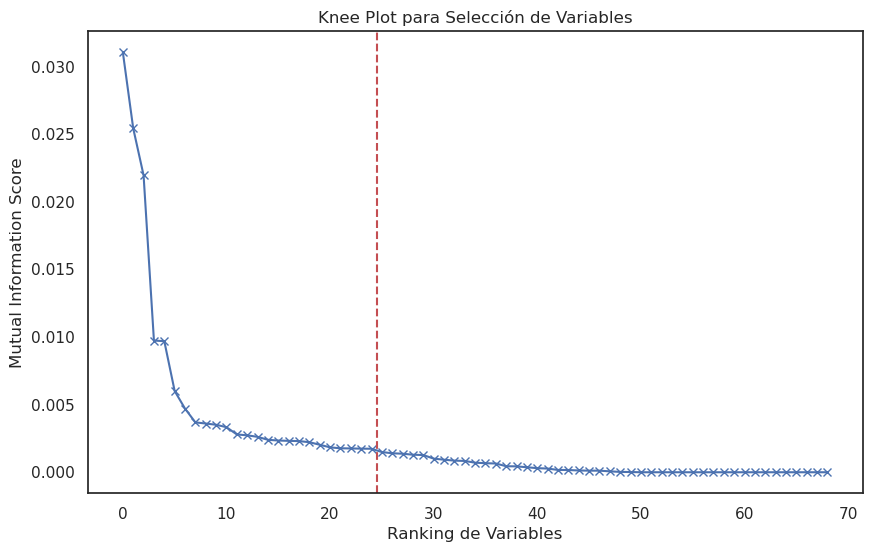

In [190]:
# --- Mutual Information Gain ---
all_features = list(num_cols) + list(cat_cols) # Combine both numerical and categorical features not date features

mi_scores = mutual_info_classif(df_proc[all_features], y, discrete_features=True)
mi_results = pd.Series(mi_scores, index=all_features).sort_values(ascending=False)

# --- Knee Plot ---
plt.figure(figsize=(10, 6))
plt.plot(range(len(all_features)), mi_results.values, 'bx-')
plt.xlabel('Ranking de Variables')
plt.ylabel('Mutual Information Score')
plt.title('Knee Plot para Selección de Variables')
plt.axvline(x=24.5, color='r', linestyle='--') # Ejemplo de punto de corte
plt.show()

> From highly correlated features  loan-amount and installment lets do a one new feature

In [191]:
mi_df = mi_results.reset_index()
mi_df.columns = ["feature", "mi_score"]

mi_df["type"] = mi_df["feature"].apply(
    lambda x: "categórica" if x in cat_cols else
              "numérica" if x in num_cols else
              "otra"
)

mi_df.head(35)



,feature,mi_score,type
0,debt_settlement_flag,0.031048,categórica
1,grade,0.025426,categórica
2,int_rate%,0.021957,numérica
3,loan_age,0.009735,numérica
4,time_since_last_payment,0.009690,numérica
5,all_util,0.006008,numérica
6,acc_open_past_24mths,0.004703,numérica
7,term,0.003686,categórica
8,open_act_il,0.003602,numérica
9,open_rv_24m,0.003511,numérica


In [192]:
features_to_drop = mi_df[mi_df.index > 25]['feature'].tolist()
if 'funded_amnt' in features_to_drop:
    features_to_drop.remove('funded_amnt')


if 'emp_length' in features_to_drop:
    features_to_drop.remove('emp_length')
    features_to_drop.append('open_rv_24m')

if 'addr_state' in features_to_drop:
    features_to_drop.remove('addr_state')

df_proc.drop(features_to_drop, axis=1, inplace=True)
df_proc['binary_loan_status'] = y

In [193]:
df_proc.head()

,acc_open_past_24mths,all_util,annual_inc,avg_cur_bal,bc_util,dti,emp_length,funded_amnt,inq_last_12m,mths_since_recent_bc,mths_since_recent_inq,num_tl_op_past_12m,open_act_il,percent_bc_gt_75,total_bc_limit,total_rev_hi_lim,int_rate%,loan_age,time_since_last_payment,grade,home_ownership,purpose,term,hardship_type,hardship_status,hardship_loan_status,debt_settlement_flag,addr_state,binary_loan_status
0,1,2,4,4,2,3,3,4,1,2,0,0,2,0,4,3,0,1,3,0,0,2,0,1,3,4,0,2,1.0
1,2,1,0,0,1,3,2,2,2,1,0,2,1,2,1,1,3,1,1,3,3,1,1,1,3,4,0,0,0.0
2,4,1,2,2,0,3,3,2,0,0,4,3,2,0,4,4,1,1,1,1,0,2,1,1,3,4,0,0,1.0
3,2,3,0,2,0,3,1,0,2,2,1,1,1,0,1,0,2,1,1,2,2,2,0,1,3,4,0,2,1.0
4,2,1,2,4,1,4,3,3,0,0,4,1,1,1,4,4,3,1,4,3,3,2,1,1,3,4,0,3,1.0


In [194]:
df_proc.to_csv('../data/FSS_correlationbased_loans.csv', index=False)

In [195]:
len(df_proc.columns)

29

In [196]:
tabla_columnas = pd.DataFrame({
    "column_name": df_proc.columns
})

tabla_columnas["type"] = tabla_columnas["column_name"].apply(
    lambda x: "categórica" if x in cat_cols else
              "numérica" if x in num_cols else
              "otra"
)

tabla_columnas


,column_name,type
0,acc_open_past_24mths,numérica
1,all_util,numérica
2,annual_inc,numérica
3,avg_cur_bal,numérica
4,bc_util,numérica
5,dti,numérica
6,emp_length,numérica
7,funded_amnt,numérica
8,inq_last_12m,numérica
9,mths_since_recent_bc,numérica


# 💠Bayesian Network

# Estrategias de Experimentación: Aprendizaje de Redes Bayesianas

[cite_start]A continuación, se detallan las diferentes configuraciones y algoritmos a probar para el aprendizaje de la estructura y los parámetros de la red, basándose en la teoría de aprendizaje de BNs[cite: 703].

## 1. Aprendizaje de Parámetros (Parameter Learning)
Una vez definida la estructura (o si se asume una fija), se deben estimar las Tablas de Probabilidad Condicional (CPTs).

* **Estimación de Máxima Verosimilitud (MLE):**
    * [cite_start]Usar frecuencias relativas puras[cite: 165].
    * [cite_start]*Nota:* Susceptible a overfitting si hay pocos datos ($N$ bajo)[cite: 168].
* **Estimación Bayesiana (Bayesian Estimation):**
    * [cite_start]Utilizar **priors de Dirichlet** para suavizar las probabilidades (evitar ceros)[cite: 173, 177].
    * **Reglas de suavizado a comparar:**
        * [cite_start]*Regla de Laplace* ($\lambda=1$): Suavizado estándar[cite: 189].
        * [cite_start]*Regla de Jeffreys-Perks* ($\lambda=0.5$): Menor impacto del prior[cite: 193].
        * [cite_start]*K2 / Lindstone* ($\lambda$ fija): Ajuste manual del hiperparámetro[cite: 188].

## 2. Aprendizaje de Estructura (Structure Learning)
El objetivo es encontrar el DAG que mejor explique los datos. [cite_start]Se deben comparar tres familias de métodos[cite: 360].

### A. Métodos basados en Restricciones (Constraint-based)
Se basan en tests estadísticos de independencia condicional (IC) para construir el esqueleto de la red.

* **Algoritmo PC (Spirtes et al.):**
    * [cite_start]Empieza con un grafo completo y elimina aristas basándose en tests de independencia condicional[cite: 377, 381].
    * [cite_start]*Parámetro clave:* Nivel de significancia $\alpha$ para el test estadístico (ej. Chi-cuadrado $\chi^2$)[cite: 389].
    * [cite_start]*Output:* Genera un CPDAG (Completed Partially DAG) que representa una clase de equivalencia[cite: 397].

### B. Métodos basados en Puntuación y Búsqueda (Score + Search)
[cite_start]Buscan la estructura que maximiza una función de puntuación (score)[cite: 365]. Se debe combinar una **métrica** con un **algoritmo de búsqueda**.

#### 1. Seleccionar la Métrica de Puntuación (Score Metric)
* **Métricas de Penalización (Information Criteria):**
    * [cite_start]**AIC (Akaike):** Penalización lineal por complejidad[cite: 562].
    * **BIC / MDL (Bayesian Info Criterion):** Penalización logarítmica (más fuerte). [cite_start]Útil para evitar overfitting en datasets grandes[cite: 564, 565].
* **Métricas Bayesianas (Bayesian Model Selection):**
    * **K2 Score:** Asume un orden topológico previo de las variables y priors uniformes. [cite_start]Fórmula cerrada, muy rápida[cite: 595, 610].
    * [cite_start]**BDeu (Likelihood-equivalent uniform):** Asume equivalencia de puntuación (grafos equivalentes tienen el mismo score) y priors uniformes[cite: 626, 627].
    * [cite_start]**BD (Bayesian Dirichlet):** La forma general[cite: 624].

#### 2. Seleccionar el Algoritmo de Búsqueda (Search Algorithm)
* **Búsqueda Local (Greedy):**
    * **Hill Climbing / Greedy Search:** Operadores locales (añadir, borrar, invertir arco). [cite_start]Rápido pero puede caer en máximos locales[cite: 649, 686].
    * [cite_start]**Algoritmo K2:** Algoritmo voraz que requiere definir un **orden** de nodos (probar diferentes ordenamientos si se usa este)[cite: 612, 616].
* **Metaheurísticas (Para evitar máximos locales):**
    * [cite_start]Simulated Annealing[cite: 686].
    * [cite_start]Algoritmos Genéticos[cite: 686].
* **Métodos Exactos:**
    * [cite_start]Programación dinámica (solo viable si $N$ es pequeño, < 30 variables)[cite: 687].

### C. Métodos Híbridos
* [cite_start]Usar un test de independencia (como PC) para restringir el espacio de búsqueda inicial y luego optimizar con un método de Score+Search[cite: 371].

## 3. Resumen de Experimentos a Ejecutar
1.  **Baseline:** Algoritmo PC (Constraint-based) vs. Hill Climbing con BIC (Score-based).
2.  **Sensibilidad de Scores:** Comparar estructura resultante usando BIC (conservador) vs. BDeu/K2.
3.  **Priors en Parámetros:** Comparar MLE vs. Estimación Bayesiana (Laplace) para ver impacto en la inferencia final.

In [6]:
import pandas as pd

df_proc = pd.read_csv('../data/FSS_correlationbased_loans.csv')

In [7]:
import ipywidgets as widgets
from IPython.display import display

def selector_de_columnas(df):
    """
    Crea una interfaz de checkboxes.
    POR DEFECTO: Todas las columnas están seleccionadas.
    """
    
    # 1. Creamos los checkboxes con value=True (marcados por defecto)
    checkboxes = [widgets.Checkbox(value=True, description=col) for col in df.columns]
    
    # 2. Botones de control
    btn_all = widgets.Button(description="Marcar Todas", icon='check')
    btn_none = widgets.Button(description="Desmarcar Todas", icon='times')
    
    # 3. Lógica de los botones
    def seleccionar_todo(b):
        for c in checkboxes: c.value = True
            
    def deseleccionar_todo(b):
        for c in checkboxes: c.value = False
            
    btn_all.on_click(seleccionar_todo)
    btn_none.on_click(deseleccionar_todo)
    
    # 4. Diseño
    box_botones = widgets.HBox([btn_all, btn_none])
    grid = widgets.GridBox(checkboxes, layout=widgets.Layout(grid_template_columns="repeat(3, 300px)"))
    
    ui = widgets.VBox([box_botones, grid])
    display(ui)
    
    # Función de retorno
    def get_selected():
        return [c.description for c in checkboxes if c.value]
        
    return get_selected

# --- USO ---
get_mis_columnas = selector_de_columnas(df_proc)

In [8]:
# 2. Obtiene la lista limpia

final_cols = get_mis_columnas()
print(final_cols)
df_bayes = df_proc[final_cols].copy()

for var in ['df', 'df_final']:
    if var in globals():
        del globals()[var]



['acc_open_past_24mths', 'all_util', 'annual_inc', 'avg_cur_bal', 'bc_util', 'dti', 'emp_length', 'funded_amnt', 'inq_last_12m', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_tl_op_past_12m', 'open_act_il', 'percent_bc_gt_75', 'total_bc_limit', 'total_rev_hi_lim', 'int_rate%', 'loan_age', 'time_since_last_payment', 'grade', 'home_ownership', 'purpose', 'term', 'hardship_type', 'hardship_status', 'hardship_loan_status', 'debt_settlement_flag', 'addr_state', 'binary_loan_status']


##  1. Creation of  standard Bayesian Network


In [5]:
import pandas as pd
import pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import (
    HillClimbSearch,
    PC,
    BIC,
    K2,
    AIC,
    BDeu,
    MaximumLikelihoodEstimator,
    BayesianEstimator,
    LogLikelihoodGauss
)

# Intentamos importar ExpertKnowledge (necesario para pgmpy >= 1.0)
try:
    from pgmpy.estimators import ExpertKnowledge
    HAS_EXPERT_KNOWLEDGE = True
except ImportError:
    HAS_EXPERT_KNOWLEDGE = False

class BayesianNetworkLearner:
    def __init__(self, data):
        self.data = data
        self.model = None
        self.structure = None

    def learn_structure(self, method='hc_bic', nodes_with_no_children=None, max_parents = None, **kwargs):
        """
        Aprende la estructura del DAG. Detecta automáticamente si usar ExpertKnowledge
        o argumentos antiguos según la versión de pgmpy instalada.
        """
        print(f"--- Iniciando aprendizaje de estructura: {method} ---")
        
        # 1. Construir la Blacklist (Restricciones)
        black_list = []
        if nodes_with_no_children:
            all_nodes = self.data.columns.tolist()
            for node in nodes_with_no_children:
                if node in all_nodes:
                    for other_node in all_nodes:
                        if node != other_node:
                            # Prohibir arista node -> other_node
                            black_list.append((node, other_node))
            print(f"Restricción aplicada: Nodos {nodes_with_no_children} sin hijos ({len(black_list)} aristas prohibidas).")

        # 2. Configurar argumentos según versión de pgmpy
        estimate_args = {}
        
        # Si existe ExpertKnowledge (versiones nuevas >= 1.0)
        if HAS_EXPERT_KNOWLEDGE and black_list:
            # Convertimos la lista de tuplas a set para ExpertKnowledge
            expert_knowledge = ExpertKnowledge(forbidden_edges=set(black_list))
            estimate_args['expert_knowledge'] = expert_knowledge
        # Si NO existe ExpertKnowledge (versiones antiguas < 1.0)
        elif not HAS_EXPERT_KNOWLEDGE and black_list:
            estimate_args['black_list'] = black_list
            
        # Parámetro epsilon común
        estimate_args['epsilon'] = 1e-4
        # Parámetro para definir el maximo número de padres
        if max_parents:
            estimate_args['max_indegree'] = kwargs.get('max_indegree', max_parents)

        # 3. Ejecutar el algoritmo
        if method == 'hc_bic':
            hc = HillClimbSearch(self.data)
            score = BIC(self.data)
            self.structure = hc.estimate(scoring_method=score, **estimate_args)
            
        elif method == 'hc_bdeu':
            hc = HillClimbSearch(self.data)
            score = BDeu(self.data, equivalent_sample_size=10)
            self.structure = hc.estimate(scoring_method=score, **estimate_args)
            
        elif method == 'hc_k2':
            hc = HillClimbSearch(self.data)
            score = K2(self.data)
            self.structure = hc.estimate(scoring_method=score, **estimate_args)
        
        elif method == 'hc_aic':
            # AIC penaliza menos que el BIC -> Redes más densas, pero controladas.
            hc = HillClimbSearch(self.data)
            scoring_obj = AIC(self.data)
            self.structure = hc.estimate(scoring_method=scoring_obj, **estimate_args)
            
        elif method == 'pc':
            if black_list:
                print("ADVERTENCIA: Las restricciones 'black_list' no se aplican directamente al algoritmo PC en esta implementación.")
            pc = PC(self.data)
            self.structure = pc.estimate(variant='stable', significance_level=0.05, ci_test='chi_square', return_type='dag')
            
        else:
            raise ValueError(f"Método '{method}' no reconocido.")
            
        print(f"Estructura aprendida: {self.structure.edges()}\n")
        return self.structure

        

    def learn_parameters(self, method='bayes_dirichlet', **kwargs):
        if self.structure is None:
            raise ValueError("Primero debes aprender la estructura (learn_structure).")

        print(f"--- Aprendiendo parámetros: {method} ---")
        self.model = DiscreteBayesianNetwork(self.structure.edges())
        
        if method == 'mle':
            self.model.fit(self.data, estimator=MaximumLikelihoodEstimator)
            
        elif method == 'bayes_bdeu':
            self.model.fit(self.data, estimator=BayesianEstimator, 
                           prior_type='BDeu', equivalent_sample_size=10)
            
        elif method == 'bayes_dirichlet':
            self.model.fit(self.data, estimator=BayesianEstimator, 
                           prior_type='dirichlet', pseudo_counts=1)
            
        elif method == 'no_params':
            pass
        
        else:
            raise ValueError(f"Método '{method}' no reconocido.")


        if method == 'no_params':
            print("¡Modelo sin parámetros aprendidos!")
        else:
            print("¡Parámetros aprendidos correctamente!")
        return self.model

    def get_model(self):
        return self.model


In [9]:
# ==========================================
# CONFIGURACIÓN
# ==========================================

# 1. Asegúrate de tener tus datos cargados en 'df_bayes'
# df_bayes = pd.read_csv('tu_archivo.csv')

# 2. Instanciar la clase
learner = BayesianNetworkLearner(df_bayes.sample(len(df_bayes), random_state=42))

# 3. CONFIGURAR RESTRICCIONES
# Lista de variables que quieres que sean "hojas" (sin hijos)
# NODOS_SIN_HIJOS = ['binary_loan_status'] 
NODOS_SIN_HIJOS = [] 

# 4. ELEGIR ESTRATEGIAS: ESTRUCTURA {hc_bic, hc_k2, hc_bdeu, hc_aic, pc}; PARAMETROS {mle, bayes_bdeu, bayes_dirichlet, no_params}
ESTRATEGIA_ESTRUCTURA = 'hc_bic' 
ESTRATEGIA_PARAMETROS = 'mle'

MAX_PARENTS = None

# 5. Ejecutar
learner.learn_structure(method=ESTRATEGIA_ESTRUCTURA, nodes_with_no_children=NODOS_SIN_HIJOS, max_parents=MAX_PARENTS)
model = learner.learn_parameters(method=ESTRATEGIA_PARAMETROS)



# 6. Verificación
# print("Modelo válido:", model.check_model())

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'acc_open_past_24mths': 'N', 'all_util': 'N', 'annual_inc': 'N', 'avg_cur_bal': 'N', 'bc_util': 'N', 'dti': 'N', 'emp_length': 'N', 'funded_amnt': 'N', 'inq_last_12m': 'N', 'mths_since_recent_bc': 'N', 'mths_since_recent_inq': 'N', 'num_tl_op_past_12m': 'N', 'open_act_il': 'N', 'percent_bc_gt_75': 'N', 'total_bc_limit': 'N', 'total_rev_hi_lim': 'N', 'int_rate%': 'N', 'loan_age': 'N', 'time_since_last_payment': 'N', 'grade': 'N', 'home_ownership': 'N', 'purpose': 'N', 'term': 'N', 'hardship_type': 'N', 'hardship_status': 'N', 'hardship_loan_status': 'N', 'debt_settlement_flag': 'N', 'addr_state': 'N', 'binary_loan_status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'acc_open_past_24mths': 'N', 'all_util': 'N', 'annual_inc': 'N', 'avg_cur_bal': 'N', 'bc_util': 'N', 'dti': 'N', 'emp_length': 'N', 'funded_amnt': 'N', '

--- Iniciando aprendizaje de estructura: hc_bic ---


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'acc_open_past_24mths': 'N', 'all_util': 'N', 'annual_inc': 'N', 'avg_cur_bal': 'N', 'bc_util': 'N', 'dti': 'N', 'emp_length': 'N', 'funded_amnt': 'N', 'inq_last_12m': 'N', 'mths_since_recent_bc': 'N', 'mths_since_recent_inq': 'N', 'num_tl_op_past_12m': 'N', 'open_act_il': 'N', 'percent_bc_gt_75': 'N', 'total_bc_limit': 'N', 'total_rev_hi_lim': 'N', 'int_rate%': 'N', 'loan_age': 'N', 'time_since_last_payment': 'N', 'grade': 'N', 'home_ownership': 'N', 'purpose': 'N', 'term': 'N', 'hardship_type': 'N', 'hardship_status': 'N', 'hardship_loan_status': 'N', 'debt_settlement_flag': 'N', 'addr_state': 'N', 'binary_loan_status': 'N'}


Estructura aprendida: [('acc_open_past_24mths', 'num_tl_op_past_12m'), ('acc_open_past_24mths', 'mths_since_recent_bc'), ('acc_open_past_24mths', 'total_rev_hi_lim'), ('all_util', 'open_act_il'), ('all_util', 'inq_last_12m'), ('all_util', 'bc_util'), ('all_util', 'avg_cur_bal'), ('annual_inc', 'avg_cur_bal'), ('annual_inc', 'emp_length'), ('annual_inc', 'open_act_il'), ('annual_inc', 'funded_amnt'), ('avg_cur_bal', 'home_ownership'), ('avg_cur_bal', 'addr_state'), ('bc_util', 'percent_bc_gt_75'), ('bc_util', 'grade'), ('dti', 'open_act_il'), ('dti', 'avg_cur_bal'), ('dti', 'annual_inc'), ('emp_length', 'home_ownership'), ('funded_amnt', 'purpose'), ('mths_since_recent_bc', 'total_bc_limit'), ('mths_since_recent_inq', 'inq_last_12m'), ('num_tl_op_past_12m', 'mths_since_recent_bc'), ('num_tl_op_past_12m', 'mths_since_recent_inq'), ('num_tl_op_past_12m', 'inq_last_12m'), ('num_tl_op_past_12m', 'loan_age'), ('num_tl_op_past_12m', 'grade'), ('num_tl_op_past_12m', 'total_bc_limit'), ('num_tl

In [10]:
from graphviz import Digraph
from IPython.display import display
import os

def visualize_dag(dag, filename=None):
    dot = Digraph(
        engine="dot",
        graph_attr={
            "rankdir": "TB",
            "ranksep": "0.25",   # ↓ separación vertical (capas)
            "nodesep": "0.35",   # ↓ separación horizontal
            "size": "8,10"
        },
        node_attr={
            "shape": "box",
            "style": "rounded,filled",
            "fillcolor": "#E1F5FE",
            "fontname": "Helvetica",
            "fontsize": "12"
        }
    )

    for u, v in dag.edges():
        dot.edge(u, v)
    
    target_node = "binary_loan_status"
    if target_node in dag.nodes():
        dot.node(target_node, fillcolor="#FED2D6") # <--- Rojo claro pastel

    # Guardar imagen
    if filename:
        folder = "../graphs"
        os.makedirs(folder, exist_ok=True)

        path = os.path.join(folder, filename)
        dot.render(path, format="png", cleanup=True)

    # Mostrar en notebook
    display(dot)



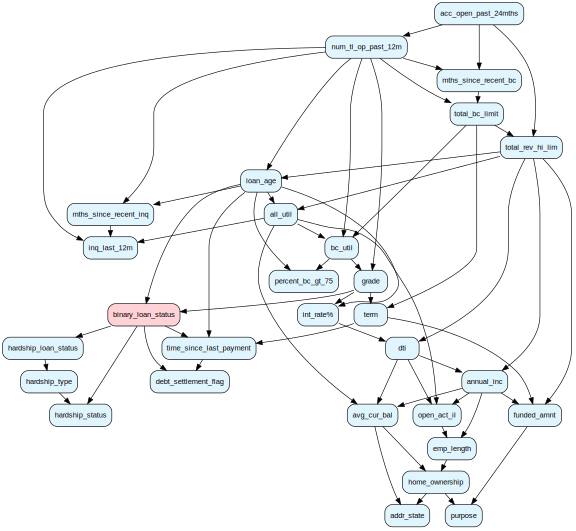

In [11]:
visualize_dag(model, "std_hc_bic_mle")

In [12]:
bin_loan_cpds = model.get_cpds('binary_loan_status')

print(bin_loan_cpds.values)


[[[0.01909308 0.05507592 0.05973451 0.04782609 0.04166667]
  [0.05839206 0.12271493 0.11292876 0.13247863 0.08823529]
  [0.10102026 0.19727647 0.17692308 0.18493151 0.13043478]
  [0.14664587 0.28216783 0.21178821 0.25396825 0.33333333]
  [0.18712871 0.35635894 0.27272727 0.26530612 0.33333333]
  [0.31178707 0.40948276 0.3081761  0.2        0.33333333]
  [0.29473684 0.50442478 0.25       0.2        0.        ]]

 [[0.98090692 0.94492408 0.94026549 0.95217391 0.95833333]
  [0.94160794 0.87728507 0.88707124 0.86752137 0.91176471]
  [0.89897974 0.80272353 0.82307692 0.81506849 0.86956522]
  [0.85335413 0.71783217 0.78821179 0.74603175 0.66666667]
  [0.81287129 0.64364106 0.72727273 0.73469388 0.66666667]
  [0.68821293 0.59051724 0.6918239  0.8        0.66666667]
  [0.70526316 0.49557522 0.75       0.8        1.        ]]]


In [ ]:
# Esto calcula y muestra todas las aserciones de independencia d-separadas
todas_indep = model.get_independencies()

# Si son demasiadas, puedes imprimir solo las primeras para ver el formato
# print(todas_indep)

(grade ⟂ annual_inc | dti, total_rev_hi_lim)
(total_bc_limit ⟂ hardship_loan_status | binary_loan_status)
(time_since_last_payment ⟂ addr_state | loan_age, binary_loan_status, term)
(mths_since_recent_inq ⟂ hardship_loan_status | binary_loan_status)
(dti ⟂ hardship_status | binary_loan_status)
(total_bc_limit ⟂ emp_length | open_act_il, annual_inc)
(num_tl_op_past_12m ⟂ hardship_status | binary_loan_status)
(dti ⟂ mths_since_recent_bc | int_rate%, total_rev_hi_lim)
(term ⟂ mths_since_recent_inq | loan_age, num_tl_op_past_12m)
(total_bc_limit ⟂ purpose | funded_amnt, home_ownership)
(hardship_loan_status ⟂ annual_inc | binary_loan_status)
(funded_amnt ⟂ inq_last_12m | annual_inc, term, total_rev_hi_lim)
(hardship_type ⟂ all_util | hardship_loan_status)
(loan_age ⟂ acc_open_past_24mths | num_tl_op_past_12m, total_rev_hi_lim)
(binary_loan_status ⟂ avg_cur_bal | all_util, dti, annual_inc)
(num_tl_op_past_12m ⟂ addr_state | avg_cur_bal, home_ownership)
(int_rate% ⟂ acc_open_past_24mths | lo

In [31]:
conectados = model.is_dconnected(
    start='annual_inc', 
    end='binary_loan_status', 
    observed=['dti']
)

print(conectados)

True


### LOAN_STATUS CALCULATIONS

In [14]:
from datetime import datetime, timedelta

def days_range_to_month_year(range_dict, reference_date=None):
    """
    Convierte rangos en días (hace X días) a rangos mes-año.
    
    Ejemplo de entrada:
    {'2593.0 - 2896.0': 0, ...}
    """
    if reference_date is None:
        reference_date = datetime.today()

    converted = {}

    for k, v in range_dict.items():
        start_days, end_days = map(float, k.split(' - '))

        # Fechas reales
        start_date = reference_date - timedelta(days=end_days)
        end_date   = reference_date - timedelta(days=start_days)

        # Formato mes-año
        label = f"{start_date.strftime('%b-%Y')} to {end_date.strftime('%b-%Y')}"

        converted[label] = v

    return converted


In [15]:
import json 

with open('../data/diccionario.json', 'r', encoding='utf-8') as f:
    label_dict = json.load(f)

print(label_dict['grade'])
print(label_dict['loan_age'])
print(days_range_to_month_year(label_dict['loan_age']))
print(label_dict['binary_loan_status'])


{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
{'2594.00 - 3428.20': 0, '3428.20 - 4262.40': 1, '4262.40 - 5096.60': 2, '5096.60 - 5930.80': 3, '5930.80 - 6765.00': 4}
{'ago.-2016 to dic.-2018': 0, 'may.-2014 to ago.-2016': 1, 'ene.-2012 to may.-2014': 2, 'oct.-2009 to ene.-2012': 3, 'jul.-2007 to oct.-2009': 4}
{'Default': 0, 'No default': 1}


In [16]:
from pgmpy.inference import VariableElimination
import pandas as pd

def obtain_parents_marginal_prob(model, target_var, label_dict):
    """
    Calcula la probabilidad marginal de la variable objetivo condicionada
    a cada uno de sus padres por separado.
    """
    # 1. Inicializar motor de inferencia
    infer = VariableElimination(model)
    
    # 2. Identificar padres
    cpd_target = model.get_cpds(target_var)
    padres = cpd_target.variables[1:]
    
    resultados = {}

    print(f"--- ANÁLISIS MARGINAL PARA: {target_var} ---")

    for padre in padres:
        
        if padre == 'loan_age':
            dict_etiquetas = days_range_to_month_year(label_dict['loan_age'])
        else:
            dict_etiquetas = label_dict.get(padre, {})

        etiquetas_padre_inv = {}
        if dict_etiquetas:
            first_key = next(iter(dict_etiquetas))
            if isinstance(first_key, str):
                etiquetas_padre_inv = {v: k for k, v in dict_etiquetas.items()}
            else:
                etiquetas_padre_inv = dict_etiquetas
        

        try:
            cardinalidad = model.get_cpds(padre).variable_card
        except AttributeError:
             cardinalidad = model.get_cardinality(padre)
        
        datos_padre = []
        
        # 3. Iterar por cada estado posible del padre
        for estado_idx in range(cardinalidad):
            q = infer.query([target_var], evidence={padre: estado_idx}, show_progress=False)
            
            prob_default = q.values[1] 
            
            nombre_estado = etiquetas_padre_inv.get(estado_idx, f"Estado {estado_idx}")
            
            datos_padre.append({
                padre: nombre_estado, 
                'Prob. Not Default': prob_default
            })
            
        df_res = pd.DataFrame(datos_padre)
        
        # df_res = df_res.sort_values('Prob. Default', ascending=False)

        df_res = df_res.set_index(padre)
        resultados[padre] = df_res
        
        print(f"\n>> Impacto Marginal de: {padre}")
        print(df_res)
        print("-" * 30)

    return resultados

In [17]:
def obtain_parents_prob(model, target_var, label_dict):
    """
    Obtiene la CPD completa (todas las combinaciones) y traduce
    los índices numéricos a texto usando el label_dict.
    """
    # 1. Obtener el objeto CPD crudo
    cpd = model.get_cpds(target_var)
    valores = cpd.get_values() # Matriz numpy
    
    # 2. Identificar variables: [Hijo, Padre1, Padre2...]
    # En pgmpy, variables[0] es el hijo, el resto son los padres en orden
    vars_cpd = cpd.variables
    hijo = vars_cpd[0]
    padres = vars_cpd[1:]
    
    print(f"--- TABLA COMPLETA PARA: {hijo} ---")
    print(f"Depende de: {padres}")

    # --- 3. CONSTRUIR ENCABEZADOS DE COLUMNA (PADRES) ---
    listas_estados_padres = []
    
    for padre in padres:
        cardinalidad = model.get_cpds(padre).variable_card
        
        # Lógica de etiquetas (reutilizando la lógica que ya te funcionó)
        if padre == 'loan_age':
            # Caso especial: transformación de días
            dict_etiquetas = days_range_to_month_year(label_dict['loan_age'])
        else:
            dict_etiquetas = label_dict.get(padre, {})

        # Invertir diccionario para buscar por índice {0: 'Texto'}
        etiquetas_inv = {}
        if dict_etiquetas:
            first_key = next(iter(dict_etiquetas))
            if isinstance(first_key, str):
                 etiquetas_inv = {v: k for k, v in dict_etiquetas.items()}
            else:
                 etiquetas_inv = dict_etiquetas
        
        # Generar lista de nombres de estados ordenada [Estado 0, Estado 1...]
        nombres_estados = [etiquetas_inv.get(i, f"{padre}_{i}") for i in range(cardinalidad)]
        listas_estados_padres.append(nombres_estados)

    # Crear MultiIndex para las columnas (Producto Cartesiano de los padres)
    if padres:
        cols = pd.MultiIndex.from_product(listas_estados_padres, names=padres)
    else:
        cols = ["Probabilidad_Marginal"]

    # --- 4. CONSTRUIR ÍNDICE DE FILAS (HIJO/TARGET) ---
    cardinalidad_hijo = cpd.variable_card
    dict_etiquetas_hijo = label_dict.get(hijo, {})
    
    # Invertir diccionario del hijo
    etiquetas_hijo_inv = {}
    if dict_etiquetas_hijo:
        first_key = next(iter(dict_etiquetas_hijo))
        if isinstance(first_key, str):
                etiquetas_hijo_inv = {v: k for k, v in dict_etiquetas_hijo.items()}
        else:
                etiquetas_hijo_inv = dict_etiquetas_hijo

    filas = [etiquetas_hijo_inv.get(i, f"{hijo}_{i}") for i in range(cardinalidad_hijo)]

    # --- 5. CREAR DATAFRAME ---
    # Nota: A veces pgmpy devuelve la matriz transpuesta o plana, pero get_values() 
    # suele ajustarse a (card_hijo, prod_card_padres)
    
    # Si hay 2+ padres, pgmpy a veces aplana la matriz de forma distinta. 
    # Esta es la forma estándar:
    try:
        df = pd.DataFrame(valores, index=filas, columns=cols)
    except ValueError:
        # Fallback por si la forma de la matriz varía según la versión
        print("Aviso: Ajustando dimensiones de la matriz...")
        df = pd.DataFrame(valores.reshape(cardinalidad_hijo, -1), index=filas, columns=cols)

    return df

In [18]:
def obtain_2_parents_prob(model, target_var, label_dict):
    """
    Función específica para cuando el Target tiene EXACTAMENTE 2 padres.
    Genera tablas cruzadas (Padre1 vs Padre2) para cada valor del Target.
    """
    # 1. Obtener datos crudos
    cpd = model.get_cpds(target_var)
    padres = cpd.variables[1:] # [Padre1, Padre2]
    
    # Verificación de seguridad
    if len(padres) != 2:
        print(f"⚠️ AVISO: Esta función es para 2 padres. Tu variable tiene {len(padres)}: {padres}")
        return None

    padre_row = padres[0] # Irá en las filas (Index)
    padre_col = padres[1] # Irá en las columnas
    
    # 2. Obtener etiquetas limpias (Filas y Columnas)
    etiquetas = {}
    
    for p in [padre_row, padre_col]:
        # Lógica especial para loan_age
        if p == 'loan_age':
             d = days_range_to_month_year(label_dict['loan_age'])
        else:
             d = label_dict.get(p, {})
             
        # Invertir diccionario {Texto: ID} -> {ID: Texto}
        if d:
            first = next(iter(d))
            if isinstance(first, str):
                etiquetas[p] = {v: k for k, v in d.items()}
            else:
                etiquetas[p] = d
        else:
            etiquetas[p] = {}

    # 3. Construir los índices (Nombres de filas y columnas)
    card_row = model.get_cpds(padre_row).variable_card
    card_col = model.get_cpds(padre_col).variable_card
    
    names_row = [etiquetas[padre_row].get(i, f"{padre_row}={i}") for i in range(card_row)]
    names_col = [etiquetas[padre_col].get(i, f"{padre_col}={i}") for i in range(card_col)]
    
    # 4. Procesar valores del Target
    # El array de valores tiene forma (card_target, card_row * card_col)
    valores_raw = cpd.get_values()
    card_target = cpd.variable_card
    
    # Etiquetas del Target (ej: 0: No Default, 1: Default)
    d_target = label_dict.get(target_var, {})
    if d_target and isinstance(next(iter(d_target)), str):
         d_target_inv = {v: k for k, v in d_target.items()}
    else:
         d_target_inv = d_target
    
    resultados = {}

    print(f"=== ANÁLISIS CRUZADO: {padre_row} (Filas) vs {padre_col} (Cols) ===")

    # 5. Generar una tabla por cada estado del Target
    for i in range(card_target):
        nombre_estado = d_target_inv.get(i, f"Target={i}")
        
        # Extraemos la fila de probabilidades correspondiente a este estado
        # y la reformamos a una matriz (Filas x Columnas)
        matriz_prob = valores_raw[i, :].reshape(card_row, card_col)
        
        df = pd.DataFrame(
            matriz_prob,
            index=pd.Index(names_row, name=padre_row),
            columns=pd.Index(names_col, name=padre_col)
        )
        
        resultados[nombre_estado] = df
        
        print(f"\n>> Probabilidad de: '{nombre_estado}'")
        # Formato condicional para verlo mejor (si usas Jupyter)
        try:
            display(df.style.background_gradient(cmap='Reds', axis=None).format("{:.2%}"))
        except:
            print(df) # Fallback para consola normal

    return resultados


In [19]:
bls_marginal = obtain_parents_marginal_prob(model, 'binary_loan_status', label_dict)

--- ANÁLISIS MARGINAL PARA: binary_loan_status ---

>> Impacto Marginal de: grade
       Prob. Not Default
grade                   
A               0.962817
B               0.909176
C               0.850057
D               0.788152
E               0.730636
F               0.649133
G               0.623988
------------------------------

>> Impacto Marginal de: loan_age
                        Prob. Not Default
loan_age                                 
ago.-2016 to dic.-2018           0.912896
may.-2014 to ago.-2016           0.820948
ene.-2012 to may.-2014           0.848494
oct.-2009 to ene.-2012           0.842362
jul.-2007 to oct.-2009           0.855074
------------------------------


In [20]:
bls_cpd = obtain_2_parents_prob(model, 'binary_loan_status', label_dict)


=== ANÁLISIS CRUZADO: grade (Filas) vs loan_age (Cols) ===

>> Probabilidad de: 'Default'


loan_age,ago.-2016 to dic.-2018,may.-2014 to ago.-2016,ene.-2012 to may.-2014,oct.-2009 to ene.-2012,jul.-2007 to oct.-2009
grade,,,,,
A,1.91%,5.51%,5.97%,4.78%,4.17%
B,5.84%,12.27%,11.29%,13.25%,8.82%
C,10.10%,19.73%,17.69%,18.49%,13.04%
D,14.66%,28.22%,21.18%,25.40%,33.33%
E,18.71%,35.64%,27.27%,26.53%,33.33%
F,31.18%,40.95%,30.82%,20.00%,33.33%
G,29.47%,50.44%,25.00%,20.00%,0.00%



>> Probabilidad de: 'No default'


loan_age,ago.-2016 to dic.-2018,may.-2014 to ago.-2016,ene.-2012 to may.-2014,oct.-2009 to ene.-2012,jul.-2007 to oct.-2009
grade,,,,,
A,98.09%,94.49%,94.03%,95.22%,95.83%
B,94.16%,87.73%,88.71%,86.75%,91.18%
C,89.90%,80.27%,82.31%,81.51%,86.96%
D,85.34%,71.78%,78.82%,74.60%,66.67%
E,81.29%,64.36%,72.73%,73.47%,66.67%
F,68.82%,59.05%,69.18%,80.00%,66.67%
G,70.53%,49.56%,75.00%,80.00%,100.00%


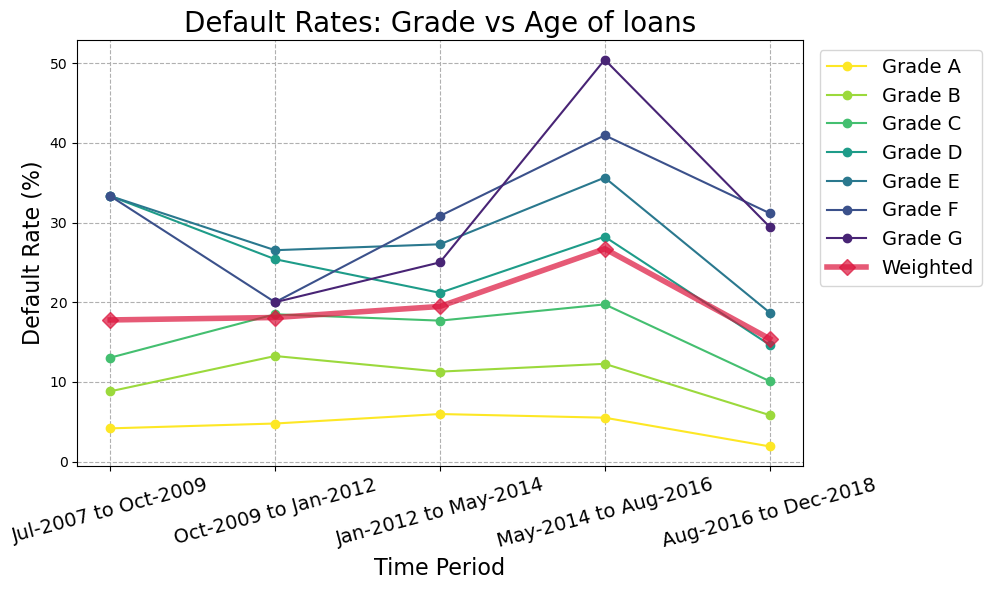

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np

# 1. Load and clean data
data_str = """
Grade,ago.-2016 to dic.-2018,may.-2014 to ago.-2016,ene.-2012 to may.-2014,oct.-2009 to ene.-2012,jul.-2007 to oct.-2009
A,98.09%,94.49%,94.03%,95.22%,95.83%
B,94.16%,87.73%,88.71%,86.75%,91.18%
C,89.90%,80.27%,82.31%,81.51%,86.96%
D,85.34%,71.78%,78.82%,74.60%,66.67%
E,81.29%,64.36%,72.73%,73.47%,66.67%
F,68.82%,59.05%,69.18%,80.00%,66.67%
G,70.53%,49.56%,75.00%,80.00%,NAN
"""
df = pd.read_csv(io.StringIO(data_str))
df.set_index('Grade', inplace=True)

# Clean % and convert to float
for col in df.columns:
    df[col] = df[col].str.replace('%', '').astype(float)

# 2. Calculate Default Rate (100 - Solvency) and reorder dates
df_default = 100 - df
df_default = df_default.iloc[:, ::-1] # Chronological order

# Rename columns to English for the X-axis
english_cols = {
    'jul.-2007 to oct.-2009': 'Jul-2007 to Oct-2009',
    'oct.-2009 to ene.-2012': 'Oct-2009 to Jan-2012',
    'ene.-2012 to may.-2014': 'Jan-2012 to May-2014',
    'may.-2014 to ago.-2016': 'May-2014 to Aug-2016',
    'ago.-2016 to dic.-2018': 'Aug-2016 to Dec-2018'
}
df_default.rename(columns=english_cols, inplace=True)

# 3. Calculate WEIGHTED CURVE (A=7 ... G=1)
weights = np.array([1.75, 1.5, 1.25, 1, 0.75, 0.5, 0.25])/2+4 # Weights aligned with rows A, B, C...

# Apply weighted average column by column
weighted_curve = df_default.apply(lambda col: np.average((col).fillna(0), weights=weights), axis=0)

# 4. Plot
plt.figure(figsize=(10, 6))

# Plot individual grades (soft)
colors = plt.cm.viridis_r(np.linspace(0, 0.9, len(df_default.index)))
for i, grade in enumerate(df_default.index):
    plt.plot(df_default.columns, df_default.loc[grade], 
             marker='o', label=f'Grade {grade}', 
             color=colors[i], alpha=1, linewidth=1.5)

# Plot WEIGHTED CURVE (highlighted)
plt.plot(weighted_curve.index, weighted_curve, 
         marker='D', markersize=8, linewidth=4, color='crimson',
         alpha = 0.7,
         label='Weighted')

plt.title('Default Rates: Grade vs Age of loans', fontsize=20)
plt.ylabel('Default Rate (%)', fontsize=16)
plt.xlabel('Time Period', fontsize=16)
plt.grid(True, linestyle='--', alpha=1)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize = 14)
plt.xticks(rotation=15, fontsize = 14)
plt.tight_layout()

plt.show()

### OTHER STUFF

In [25]:
label_dict['annual_inc']

{'0.00 - 42000.00': 0,
 '42000.00 - 58000.00': 1,
 '58000.00 - 75000.00': 2,
 '75000.00 - 100000.00': 3,
 '100000.00 - 9300000.00': 4}

In [27]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model)

print("--- PRUEBA DE INDEPENDENCIA CONDICIONAL ---")

# 1. Comprobar estructuralmente si están D-conectados
# ¿Existe un camino activo entre Ingresos y Status si NO sabemos nada?
conectado_sin_evidencia = model.is_dconnected('binary_loan_status', 'annual_inc')
print(f"¿Están conectados 'annual_inc' y 'binary_loan_status' sin evidencia?: {conectado_sin_evidencia}")

# 2. Comprobar si observar 'dti' rompe la conexión (D-Separación)
conectado_con_dti = model.is_dconnected('binary_loan_status', 'annual_inc', observed=['dti'])
print(f"¿Siguen conectados si observamos 'dti'?: {conectado_con_dti}")

print("\n--- PRUEBA EMPÍRICA (INFERENCIA) ---")

# Caso Base: Probabilidad a priori de Default
base_prob = infer.query(['binary_loan_status'], show_progress=False).values[0] # Asumiendo 1 = Default
print(f"Prob. Base de Default: {base_prob:.4f}")

# Caso A: Solo sabemos que gana mucho dinero
prob_inc = infer.query(['binary_loan_status'], evidence={'annual_inc': 4}, show_progress=False).values[0]
print(f"Prob. Default | Income=4: {prob_inc:.4f}")

# Caso B: Gana mucho dinero, pero tiene DTI Alto (Endeudado)
prob_inc_dti = infer.query(['binary_loan_status'], evidence={'annual_inc': 4, 'dti': 4}, show_progress=False).values[1]
print(f"Prob. Default | Income=4, DTI=4: {prob_inc_dti:.4f}")

# Caso C: Solo sabemos que tiene DTI Alto (Ignoramos ingresos)
prob_dti = infer.query(['binary_loan_status'], evidence={'dti': 4}, show_progress=False).values[0]
print(f"Prob. Default | DTI=4: {prob_dti:.4f}")

# CONCLUSIÓN AUTOMÁTICA
diff = abs(prob_inc_dti - prob_dti)
if diff < 0.01:
    print(f"\n✅ HIPÓTESIS VALIDADA: La diferencia es despreciable ({diff:.4f}).")
    print("Conocer 'annual_inc' no aporta información extra si ya conocemos 'dti'.")
else:
    print(f"\n❌ HIPÓTESIS REFUTADA: Hay una diferencia de {diff:.4f}.")
    print("El ingreso sigue importando incluso conociendo el DTI.")

--- PRUEBA DE INDEPENDENCIA CONDICIONAL ---
¿Están conectados 'annual_inc' y 'binary_loan_status' sin evidencia?: True
¿Siguen conectados si observamos 'dti'?: True

--- PRUEBA EMPÍRICA (INFERENCIA) ---
Prob. Base de Default: 0.1319
Prob. Default | Income=4: 0.1217
Prob. Default | Income=4, DTI=4: 0.8539
Prob. Default | DTI=4: 0.1530

❌ HIPÓTESIS REFUTADA: Hay una diferencia de 0.7009.
El ingreso sigue importando incluso conociendo el DTI.


In [ ]:
print("--- ESCENARIOS WHAT-IF (Inferencia Causal) ---")

# --- ESCENARIO 1: EL PERFIL 'INMACULADO' VS 'RIESGOSO' ---
# Comparamos extremos para ver la sensibilidad del modelo

# Perfil Bueno: Grado A, Casa Propia (hipoteca), Plazo corto
q_good = infer.query(['binary_loan_status'], 
                     evidence={'grade': 'A', 'home_ownership': 'MORTGAGE', 'term': ' 36 months'},
                     show_progress=False)

# Perfil Malo: Grado E, Alquiler, Plazo largo
q_bad = infer.query(['binary_loan_status'], 
                    evidence={'grade': 'E', 'home_ownership': 'RENT', 'term': ' 60 months'},
                    show_progress=False)

print(f"Riesgo Perfil 'Inmaculado': {q_good.values[1]:.2%}")
print(f"Riesgo Perfil 'Riesgoso':   {q_bad.values[1]:.2%}")


# --- ESCENARIO 2: STRESS TEST DE LA CRISIS (LOAN AGE) ---
# ¿Cómo afecta la antigüedad del préstamo (vintage) al riesgo percibido?

# Usamos los rangos de fechas que tienes en tu dataset
periodo_crisis = 'jul.-2007 to oct.-2009' 
periodo_reciente = 'ago.-2016 to dic.-2018'

print(f"\n--- IMPACTO DEL CICLO ECONÓMICO (Vintage) ---")

try:
    risk_2008 = infer.query(['binary_loan_status'], evidence={'loan_age': periodo_crisis}, show_progress=False).values[1]
    risk_2018 = infer.query(['binary_loan_status'], evidence={'loan_age': periodo_reciente}, show_progress=False).values[1]

    print(f"Riesgo estimado en Crisis (2007-2009): {risk_2008:.2%}")
    print(f"Riesgo estimado en Bonanza (2016-2018): {risk_2018:.2%}")
except Exception as e:
    print("Error: Verifica que las etiquetas de 'loan_age' coincidan exactamente con tu dataset.")

In [ ]:
print("--- ANÁLISIS DEL MANTO DE MARKOV ---")

target = 'binary_loan_status'
mb = model.get_markov_blanket(target)

print(f"El Manto de Markov de '{target}' contiene {len(mb)} variables:")
print(mb)

# --- DETECCIÓN DE LEAKAGE ---
# Analizamos si hay variables "prohibidas" en el Manto.
# Estas variables son consecuencias del impago, no precursores.

leakage_vars = ['hardship_loan_status', 'hardship_type', 'hardship_status', 
                'debt_settlement_flag', 'time_since_last_payment']

found_leakage = [var for var in mb if var in leakage_vars]

if found_leakage:
    print("\n⚠️ ALERTA CRÍTICA DE DATA LEAKAGE ⚠️")
    print(f"Se han encontrado variables del FUTURO en el Manto de Markov: {found_leakage}")
    print("Estas variables 'chivan' la respuesta al modelo. Deben ser eliminadas para un modelo predictivo real.")
    print("Recomendación: Elimina estos nodos y re-entrena la estructura.")
else:
    print("\n✅ El Manto parece limpio de variables de 'Hardship' o 'Settlement'.")

## 2. Variable elimination.

In [ ]:
from pgmpy.inference import VariableElimination
infer = VariableElimination(model)
prob = infer.query(variables=['binary_loan_status'], 
                   evidence={'grade': label_dict['grade']['F'], 'home_ownership': label_dict['home_ownership']['own']})
print(prob)

print(label_dict['binary_loan_status'])

+-------------------------+---------------------------+
| binary_loan_status      |   phi(binary_loan_status) |
+=========================+===========================+
| binary_loan_status(0.0) |                    0.3341 |
+-------------------------+---------------------------+
| binary_loan_status(1.0) |                    0.6659 |
+-------------------------+---------------------------+
{'Default': 0, 'No default': 1}


Calculando probabilidades para 28 escenarios...

--- Top Escenarios de Mayor Riesgo ---
   grade home_ownership  Prob_Default
1      A          other      0.962541
2      A            own      0.962116
0      A       mortgage      0.960821
3      A           rent      0.960571
5      B          other      0.913006
6      B            own      0.911397
4      B       mortgage      0.909267
7      B           rent      0.908820
9      C          other      0.859239
10     C            own      0.855310

--- Matriz de Calor (Pivot Table) ---
home_ownership  mortgage     other       own      rent
grade                                                 
A               0.960821  0.962541  0.962116  0.960571
B               0.909267  0.913006  0.911397  0.908820
C               0.851905  0.859239  0.855310  0.851053
D               0.787774  0.795541  0.791325  0.786836
E               0.732600  0.744241  0.737301  0.731197
F               0.663273  0.667935  0.665872  0.662595
G              

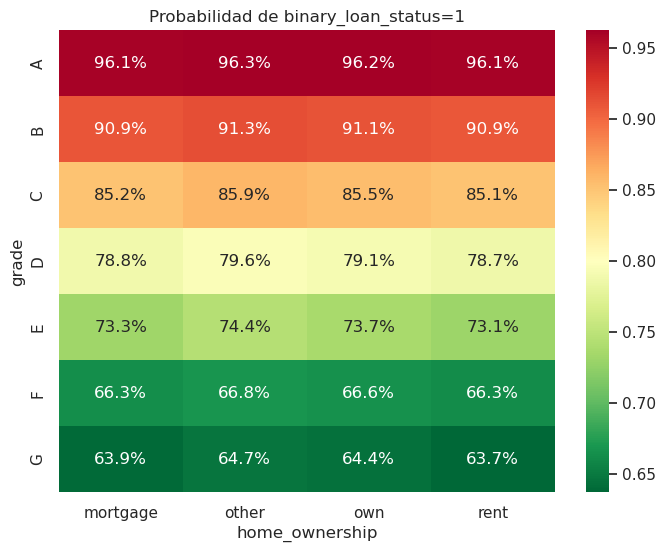

In [ ]:
import pandas as pd
import itertools

# 1. Configuración: Variables que quieres analizar como causas (Evidence)
# Puedes añadir más a esta lista (ej: 'verification_status', 'purpose')
variables_analisis = ['grade', 'home_ownership']
target = 'binary_loan_status'

# 2. Preparamos los diccionarios inversos para que la tabla final sea legible (texto, no números)
# label_dict tiene la forma {'col': {'A':0, 'B':1}}. Necesitamos lo contrario.
inv_label_dict = {
    col: {v: k for k, v in mapping.items()} 
    for col, mapping in label_dict.items()
}

# 3. Generamos todas las combinaciones posibles de valores numéricos
# Extraemos los valores posibles de cada variable del label_dict original
valores_posibles = [list(label_dict[var].values()) for var in variables_analisis]
# itertools.product crea el producto cartesiano (todas las combinaciones)
combinaciones = list(itertools.product(*valores_posibles))

print(f"Calculando probabilidades para {len(combinaciones)} escenarios...")

resultados = []

# 4. Bucle de Inferencia
for comb in combinaciones:
    # Creamos el diccionario de evidencia: ej {'grade': 0, 'home_ownership': 1}
    evidence = dict(zip(variables_analisis, comb))
    
    # Consultamos al modelo
    try:
        q = infer.query(variables=[target], evidence=evidence, show_progress=False)
        
        # Obtenemos la probabilidad del evento '1' (asumiendo que 1 es Default/Malo)
        # q.values suele ser un array [Prob_0, Prob_1]
        prob_default = q.values[1] 
        
        # Guardamos los datos decodificados (leíbles)
        fila = {var: inv_label_dict[var][val] for var, val in evidence.items()}
        fila['Prob_Default'] = prob_default
        resultados.append(fila)
        
    except Exception as e:
        print(f"Error en combinación {evidence}: {e}")

# 5. Crear el DataFrame
df_resultados = pd.DataFrame(resultados)

# --- VISUALIZACIÓN 1: Tabla Plana Ordenada ---
print("\n--- Top Escenarios de Mayor Riesgo ---")
print(df_resultados.sort_values('Prob_Default', ascending=False).head(10))

# --- VISUALIZACIÓN 2: Tabla Cruzada (Pivot Table) ---
# Ideal para ver Grado vs Vivienda
if len(variables_analisis) == 2:
    print("\n--- Matriz de Calor (Pivot Table) ---")
    pivot_table = df_resultados.pivot(
        index=variables_analisis[0], 
        columns=variables_analisis[1], 
        values='Prob_Default'
    )
    # Ordenamos un poco si es posible (alfabéticamente o por índice si coincide)
    print(pivot_table)

    # Opcional: Visualizar con Seaborn si quieres mapa de calor gráfico
    import seaborn as sns
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 6))
    sns.heatmap(pivot_table, annot=True, fmt=".1%", cmap="RdYlGn_r")
    plt.title(f"Probabilidad de {target}=1")
    plt.show()

### 4 Más pruebas


--- INICIO DE ANÁLISIS AVANZADO ---

[A] PREDICCIÓN DE UN NUEVO CLIENTE
Probabilidad de Default para el cliente {'grade': 0, 'home_ownership': 2}:
+-------------------------+---------------------------+
| binary_loan_status      |   phi(binary_loan_status) |
+=========================+===========================+
| binary_loan_status(0.0) |                    0.0379 |
+-------------------------+---------------------------+
| binary_loan_status(1.0) |                    0.9621 |
+-------------------------+---------------------------+

[B] ANÁLISIS DEL MANTO DE MARKOV
Las variables clave (Markov Blanket) para 'binary_loan_status' son:
['loan_age', 'term', 'grade', 'time_since_last_payment', 'debt_settlement_flag', 'hardship_status']
NOTA: Cualquier variable fuera de esta lista es estadísticamente irrelevante si ya conoces estas.

[C] ANÁLISIS WHAT-IF: IMPACTO DE POLÍTICAS
Probabilidad de 'grade' dado que PAGA BIEN:
+----------+--------------+
| grade    |   phi(grade) |
+==========+=====

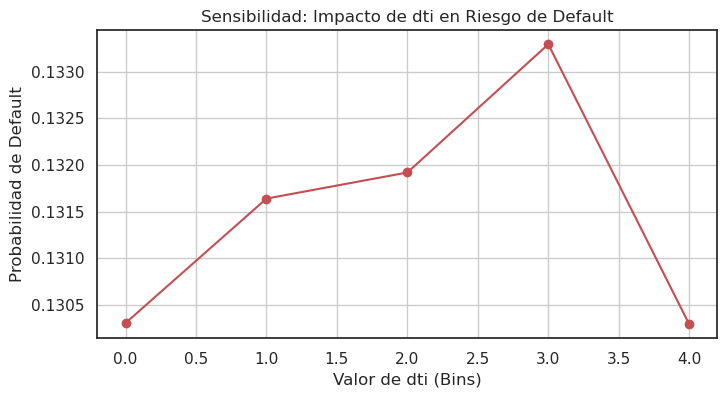

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pgmpy.inference import VariableElimination

# ---------------------------------------------------------
# 0. PREPARACIÓN
# ---------------------------------------------------------
# Inicializamos el motor de inferencia
infer = VariableElimination(model)
target_var = 'binary_loan_status' # Asegúrate que este es el nombre exacto de tu nodo objetivo

print("--- INICIO DE ANÁLISIS AVANZADO ---")

# ---------------------------------------------------------
# A. INFERENCIA (PREDICCIÓN INDIVIDUAL)
# ---------------------------------------------------------
print("\n[A] PREDICCIÓN DE UN NUEVO CLIENTE")
# Define las características del cliente (usa los números de tu diccionario.json)
# Por ejemplo: Grade=0 (A), Home=2 (RENT)
evidencia_cliente = {
    'grade': 0,            
    'home_ownership': 2    
}
try:
    prob = infer.query(variables=[target_var], evidence=evidencia_cliente)
    print(f"Probabilidad de Default para el cliente {evidencia_cliente}:")
    print(prob)
except Exception as e:
    print(f"Error en inferencia: {e}. Revisa que los nombres de variables y valores coincidan con el modelo.")


# ---------------------------------------------------------
# B. MANTO DE MARKOV (MARKOV BLANKET)
# ---------------------------------------------------------
print("\n[B] ANÁLISIS DEL MANTO DE MARKOV")
# Variables que 'blindan' al target. Son las ÚNICAS que importan.
mb = model.get_markov_blanket(target_var)
print(f"Las variables clave (Markov Blanket) para '{target_var}' son:")
print(mb)
print("NOTA: Cualquier variable fuera de esta lista es estadísticamente irrelevante si ya conoces estas.")


# ---------------------------------------------------------
# C. ANÁLISIS WHAT-IF (SIMULACIÓN DE ESCENARIOS)
# ---------------------------------------------------------
print("\n[C] ANÁLISIS WHAT-IF: IMPACTO DE POLÍTICAS")
# Escenario: ¿Cómo cambia la distribución de 'grade' si sabemos que el préstamo NO entró en default (status=1)?
# vs. si SÍ entró en default (status=0)?

var_interes = 'grade' # La variable que queremos observar

# Caso 1: Préstamo pagado (Status = 1)
prob_pagado = infer.query(variables=[var_interes], evidence={target_var: 1})
# Caso 2: Default (Status = 0)
prob_default = infer.query(variables=[var_interes], evidence={target_var: 0})

print(f"Probabilidad de '{var_interes}' dado que PAGA BIEN:\n{prob_pagado}")
print(f"Probabilidad de '{var_interes}' dado que hace DEFAULT:\n{prob_default}")


# ---------------------------------------------------------
# D. DETECCIÓN DE ANOMALÍAS (BASADA EN PROBABILIDAD)
# ---------------------------------------------------------
print("\n[D] DETECCIÓN DE ANOMALÍAS (SCORING)")
# Calculamos la probabilidad de una combinación específica
# Caso extraño: Grade excelente (0) pero con int_rate muy alto (suponiendo bin 4)
caso_raro = {'grade': 0, 'int_rate': 4} 

# Nota: pgmpy calcula P(A|B), para probabilidad conjunta P(A,B) usamos query
try:
    # Preguntamos por la prob de grade=0 DADO int_rate=4
    prob_anomalia = infer.query(variables=['grade'], evidence={'int_rate': 4})
    val_prob = prob_anomalia.values[0] # Prob de grade=0
    print(f"Probabilidad de tener Grade=0 dado Int_Rate=4: {val_prob:.4f}")
    if val_prob < 0.05:
        print("ALERT: ¡Esta combinación es altamente improbable! Posible error de datos o fraude.")
    else:
        print("Combinación dentro de lo normal.")
except:
    print("Saltando detección de anomalías (verifica que las variables existan en el grafo).")


# ---------------------------------------------------------
# E. ANÁLISIS DE SENSIBILIDAD
# ---------------------------------------------------------
print("\n[E] ANÁLISIS DE SENSIBILIDAD")
# ¿Cuánto varía el riesgo de default si movemos una variable (ej. 'dti') de mínimo a máximo?
var_sens = 'dti' # Variable a testear
resultados_sens = []

# Asumimos que 'dti' tiene bins del 0 al 4 (según tu discretizer)
posibles_valores = [0, 1, 2, 3, 4] 

print(f"Variando '{var_sens}' y observando probabilidad de Default...")
for val in posibles_valores:
    try:
        q = infer.query(variables=[target_var], evidence={var_sens: val})
        prob_default_val = q.values[0] # Asumiendo que 0 es el índice de default en tu target
        resultados_sens.append(prob_default_val)
        print(f"  {var_sens}={val} -> Prob Default: {prob_default_val:.2%}")
    except:
        pass

# Graficamos
plt.figure(figsize=(8, 4))
plt.plot(posibles_valores, resultados_sens, marker='o', linestyle='-', color='r')
plt.title(f'Sensibilidad: Impacto de {var_sens} en Riesgo de Default')
plt.xlabel(f'Valor de {var_sens} (Bins)')
plt.ylabel('Probabilidad de Default')
plt.grid(True)
plt.show()

In [ ]:
from pgmpy.estimators import TreeSearch, HillClimbSearch, BIC, K2, BDeu
from pgmpy.models import BayesianNetwork

# Datos procesados (asegúrate de usar tu DF discretizado df_bayes)
data = df_bayes.copy()
data

print("--- COMPARACIÓN DE ALGORITMOS DE APRENDIZAJE ---")

# ---------------------------------------------------------
# MÉTODO 1: Chow-Liu (Estructura de Árbol)
# ---------------------------------------------------------
print("\n1. Entrenando Chow-Liu (Tree Search)...")
est_tree = TreeSearch(data, root_node=target_var)
# Chow-Liu calcula la mejor estructura de árbol
dag_tree = est_tree.estimate(estimator_type="chow-liu")
model_tree = DiscreteBayesianNetwork(dag_tree)
print(f"  -> Nodos: {len(model_tree.nodes())}, Aristas: {len(model_tree.edges())}")

# ---------------------------------------------------------
# MÉTODO 2: HillClimb con Score K2
# ---------------------------------------------------------
print("\n2. Entrenando HillClimb con K2 Score...")
# K2 a veces encuentra estructuras más densas que BIC
hc_k2 = HillClimbSearch(data)
k2_score = K2(data)
dag_k2 = hc_k2.estimate(scoring_method=k2_score, max_iter=int(1e4))
model_k2 = DiscreteBayesianNetwork(dag_k2)
print(f"  -> Nodos: {len(model_k2.nodes())}, Aristas: {len(model_k2.edges())}")

# ---------------------------------------------------------
# MÉTODO 3: Tu modelo original (HillClimb + BIC)
# ---------------------------------------------------------
print("\n3. Modelo Original (HillClimb + BIC)...")
# (Solo para referencia, ya lo tienes entrenado)
hc_bic = HillClimbSearch(data)
bic_score = BIC(data)
dag_bic = hc_bic.estimate(scoring_method=bic_score, max_iter=int(1e4))
model_bic = DiscreteBayesianNetwork(dag_bic)
print(f"  -> Nodos: {len(model_bic.nodes())}, Aristas: {len(model_bic.edges())}")

# ---------------------------------------------------------
# COMPARACIÓN VISUAL RÁPIDA (Solo conteo de padres)
# ---------------------------------------------------------
print("\n--- Comparación: ¿Cuántos padres tiene 'loan_status' en cada modelo? ---")
target = target_var

try:
    print(f"Chow-Liu: {model_tree.get_parents(target)}")
    print(f"HC (K2):  {model_k2.get_parents(target)}")
    print(f"HC (BIC): {model_bic.get_parents(target)}")
except:
    print("El target no está en alguno de los modelos o nombre incorrecto.")

print("\nCONSEJO: Usa el modelo 'HC (BIC)' si quieres simplicidad (menos aristas). Usa 'HC (K2)' si tienes muchos datos y quieres capturar relaciones más complejas.")

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'acc_open_past_24mths': 'N', 'all_util': 'N', 'annual_inc': 'N', 'avg_cur_bal': 'N', 'bc_util': 'N', 'dti': 'N', 'inq_last_12m': 'N', 'mths_since_recent_bc': 'N', 'mths_since_recent_inq': 'N', 'num_tl_op_past_12m': 'N', 'open_act_il': 'N', 'open_rv_24m': 'N', 'percent_bc_gt_75': 'N', 'total_bc_limit': 'N', 'total_rev_hi_lim': 'N', 'int_rate%': 'N', 'loan_age': 'N', 'time_since_last_payment': 'N', 'grade': 'N', 'home_ownership': 'N', 'purpose': 'N', 'term': 'N', 'hardship_type': 'N', 'hardship_status': 'N', 'hardship_loan_status': 'N', 'debt_settlement_flag': 'N', 'binary_loan_status': 'N'}


--- COMPARACIÓN DE ALGORITMOS DE APRENDIZAJE ---

1. Entrenando Chow-Liu (Tree Search)...


Building tree:   0%|          | 0/351.0 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'acc_open_past_24mths': 'N', 'all_util': 'N', 'annual_inc': 'N', 'avg_cur_bal': 'N', 'bc_util': 'N', 'dti': 'N', 'inq_last_12m': 'N', 'mths_since_recent_bc': 'N', 'mths_since_recent_inq': 'N', 'num_tl_op_past_12m': 'N', 'open_act_il': 'N', 'open_rv_24m': 'N', 'percent_bc_gt_75': 'N', 'total_bc_limit': 'N', 'total_rev_hi_lim': 'N', 'int_rate%': 'N', 'loan_age': 'N', 'time_since_last_payment': 'N', 'grade': 'N', 'home_ownership': 'N', 'purpose': 'N', 'term': 'N', 'hardship_type': 'N', 'hardship_status': 'N', 'hardship_loan_status': 'N', 'debt_settlement_flag': 'N', 'binary_loan_status': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'acc_open_past_24mths': 'N', 'all_util': 'N', 'annual_inc': 'N', 'avg_cur_bal': 'N', 'bc_util': 'N', 'dti': 'N', 'inq_last_12m': 'N', 'mths_since_recent_bc': 'N', 'mths_since_recent_inq': 'N'

  -> Nodos: 27, Aristas: 26

2. Entrenando HillClimb con K2 Score...


  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 